# Notebook 1 of 3 — Research Foundations: Measuring, Routing and Monitoring a Hybrid Rules + LLM Classifier

This notebook is the mathematical foundation of a 3-notebook project exploring a common production
pattern: a text-classification pipeline built from cheap keyword-taxonomy rules plus an LLM fallback
tier for anything the rules can't resolve — here, deciding whether a job posting genuinely involves
substantive GenAI/LLM work. The motivating questions are practical ones any team running such a
pipeline eventually faces: where should the rule/LLM boundary sit, how do you measure precision/recall
rigorously from a small human audit, and how do you monitor the pipeline for real degradation over time
without drowning in false alarms?

This notebook builds, from first principles and with **Monte Carlo verification of every guarantee**,
the statistics behind three papers chosen to tell one story — **measure → decide → monitor**:

1. **Measure — Prediction-Powered Inference (PPI).** Angelopoulos, Bates, Fannjiang, Jordan, Zrnic.
   *Science*, Vol. 382, No. 6671, pp. 669–674, 2023. UC Berkeley. arXiv:2301.09633.
2. **Decide — BARGAIN**: *"Cut Costs, Not Accuracy: LLM-Powered Data Processing with Guarantees."*
   Zeighami, Shankar, Parameswaran. UC Berkeley. SIGMOD 2026. arXiv:2509.02896.
3. **Monitor — PPRM**: *"Prediction-Powered Risk Monitoring of Deployed Models for Detecting Harmful
   Distribution Shifts."* Zhang, Cai, Yu, Simeone. Zhejiang University / Northeastern University London.
   ICML 2026. arXiv:2602.02229.

The shared toolkit across all three: **rectified prediction-powered estimators** (impute with a cheap
model, correct the bias on a small labeled sample) and **anytime-valid confidence sequences** built by
"testing by betting" (Waudby-Smith & Ramdas). Notebooks 2–3 apply this toolkit to a synthetic
job-posting corpus with real DeepSeek LLM calls.

**Framing (read before anything else):** every number below is labeled as either (a) **quoted from a
paper**, cited by section/theorem/equation number and checked against the paper's own text, or (b) a
**toy simulation** produced in this notebook — these numbers describe *nothing about any real production
system*, only whether an estimator/interval behaves as its theorem claims. Material that is **not** in
the three papers (Wilson intervals, MinHash/LSH, PPI++, the stratified/label-shift bootstrap, a
permutation test) is explicitly labeled *"derived here — not from the three papers"* with a standard
reference. Where a source paper's stated formula looked numerically inconsistent, the textbook form was
implemented instead and verified by simulation — this happened once, in §4 (the predictable KT-style
running mean/variance in Lemma B.1), and is called out there. §7 implements PPRM's own Lemma 2.1 (CM-EB)
bound with the mixing distribution $q(\lambda)$ discretized to a 200-point grid — an implementation
choice, also called out there.

Each of the 8 sections below has the same shape: **markdown (claim + quotes) → computation cell(s) that
print self-checks and never plot → "How to read this chart" → one visualization cell that only plots
what the computation cell already computed.** One palette, defined once below, is reused throughout.

In [ ]:
# This environment's matplotlib defaults to the non-interactive 'agg' backend (no display
# attached); %matplotlib inline switches a real Jupyter kernel to the inline backend so charts
# render normally. Run this once, first cell.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist
import hashlib
import time

RNG_SEED = 20250917
Z95 = NormalDist().inv_cdf(0.975)   # two-sided 95% normal quantile

# ---------------------------------------------------------------------------
# One palette, defined once, reused in every visualization cell.
# ---------------------------------------------------------------------------
PALETTE = {
    "classical": "#7f7f7f",   # grey  -- classical / naive / SRM (labeled-only) baselines
    "naive":     "#7f7f7f",
    "srm":       "#7f7f7f",
    "wald":      "#7f7f7f",
    "ppi":       "#1f77b4",   # blue  -- PPI / PPRM (prediction-powered) methods
    "pprm":      "#1f77b4",
    "pprm_fixed":   "#1f77b4",
    "pprm_adaptive":"#17becf",
    "wilson":    "#1f77b4",
    "bargain":   "#ff7f0e",   # orange -- BARGAIN / betting-based methods
    "betting":   "#ff7f0e",
    "peeking":   "#d62728",   # red   -- invalid "peeking" comparator
    "truth":     "black",     # black dashed -- ground truth / target reference lines
}

# ---------------------------------------------------------------------------
# Shared helpers used across sections (documented once here; re-used, not
# redefined, in later cells).
# ---------------------------------------------------------------------------

def wald_ci(k, n, z=Z95):
    '''Classical Wald interval for a binomial proportion. Vectorized over k, n.'''
    phat = k / n
    se = np.sqrt(phat * (1 - phat) / n)
    return phat - z * se, phat + z * se


def wilson_ci(k, n, z=Z95):
    '''Wilson score interval (derived here -- not from the three papers; standard
    reference: Wilson 1927; Brown, Cai & DasGupta 2001, Statistical Science).
    Vectorized over k, n.'''
    phat = k / n
    denom = 1 + z ** 2 / n
    center = (phat + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z ** 2 / (4 * n ** 2)) / denom
    return center - half, center + half


def bargain_wealth(Y, m, alpha):
    '''Running wealth K(m, Y[:i]) from BARGAIN Lemma B.1 (Appendix B.1),
    using the predictable KT-style plug-in mu_i, sigma_i^2 (the standard Waudby-Smith
    & Ramdas 2020 form). NOTE: the raw trace text renders mu_i = 1/2 + sum(Y_j)/(i+1),
    which is numerically wrong (it lets mu drift outside [0,1] and makes the martingale
    misbehave); the textbook / standard form divides the WHOLE numerator (const + sum)
    by (i+1). We implement the standard form and verify it by simulation (Sec 4), following
    a general rule used throughout this notebook: if a source formula looks malformed,
    implement the standard textbook form, verify it by simulation, and say so.
    Y: array (S, T) of values (typically in [0,1]). Returns wealth path, shape (S, T).'''
    S, T = Y.shape
    if T == 0:
        return np.ones((S, 0))
    i = np.arange(1, T + 1)
    cs_y = np.cumsum(Y, axis=1)
    mu = (0.5 + cs_y) / (i + 1)[None, :]
    sq = (Y - mu) ** 2
    cs_sq = np.cumsum(sq, axis=1)
    sigma2 = (0.25 + cs_sq) / (i + 1)[None, :]
    sigma2_prev = np.concatenate([np.full((S, 1), 0.25), sigma2[:, :-1]], axis=1)
    lam = np.sqrt(2 * np.log(2 / alpha) / (i[None, :] * np.log(i[None, :] + 1) * sigma2_prev))
    lam = np.minimum(lam, 3 / (4 * m))
    factors = 1 + lam * (Y - m)
    factors = np.maximum(factors, 1e-300)
    logK = np.cumsum(np.log(factors), axis=1)
    return np.exp(np.minimum(logK, 700))


def first_crossing(K, threshold):
    '''First index (1-based) where K >= threshold along axis=1, else -1.'''
    cross = K >= threshold
    any_cross = np.any(cross, axis=1)
    first = np.argmax(cross, axis=1)
    return np.where(any_cross, first + 1, -1)

print("Palette and shared helpers (wald_ci, wilson_ci, bargain_wealth, first_crossing) ready.")


Palette and shared helpers (wald_ci, wilson_ci, bargain_wealth, first_crossing) ready.


## 1. Classification metrics are population parameters — and the interval you put on them matters

Three quantities the audit cares about, all population parameters of an unknown distribution $P$ over
(posting, true label) pairs:

- **Prevalence** $\pi = P(Y=1)$ — how common is the class of interest.
- **Precision** $P(Y=1 \mid \hat Y=1)$ — a *conditional mean of $Y$ over predicted positives*. You can
  estimate it by sampling **predicted positives** and checking their true label — cheap, because you
  choose which subpopulation to sample.
- **Recall** $P(\hat Y=1 \mid Y=1)$ — conditions on the **unobserved** true label. You cannot sample
  "true positives" directly; you must sample from the *whole* population and wait for positives to show
  up. This is why recall is the expensive metric to pin down — a fact that foreshadows BARGAIN's
  recall-target impossibility result in §6.

Any of these is a proportion $\hat p = k/n$, and every one of them needs a confidence interval, not just
a point estimate, because $n$ is always finite. The standard **Wald interval**
$\hat p \pm z_{1-\alpha/2}\sqrt{\hat p(1-\hat p)/n}$ is the one most people reach for — and it is known to
undercover badly when $p$ is close to 0 or 1 or $n$ is small, exactly the regime a rare positive class
(a "GenAI role" tag at 10-15% prevalence) or a high-precision rule (95%+) lives in. The **Wilson score
interval** inverts the normal approximation to the *score* test instead of the Wald test and is far
better behaved in this regime.

*(Both intervals below are* ***derived here — not from the three papers***. *Standard references: Wilson,
E.B. (1927), "Probable Inference, the Law of Succession, and Statistical Inference," JASA; Brown, Cai &
DasGupta (2001), "Interval Estimation for a Binomial Proportion," Statistical Science. The three papers'
own interval constructions — PPI's normal-approximation and betting intervals, BARGAIN's betting bound,
PPRM's CM-EB / betting confidence sequence — are covered in §2, §4, and §7.)*

$$\text{Wald: } \hat p \pm z_{1-\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}} \qquad\qquad
\text{Wilson: } \frac{\hat p + \frac{z^2}{2n}}{1+\frac{z^2}{n}} \pm \frac{z\sqrt{\frac{\hat p(1-\hat
p)}{n}+\frac{z^2}{4n^2}}}{1+\frac{z^2}{n}}$$

In [2]:
# Monte Carlo coverage of Wald vs. Wilson at the 95% nominal level, over a grid of
# (n, p) chosen to span "recall-like" (moderate p, small n) and "precision-like"
# (p near 1, moderate n) regimes an audit would actually see.
rng = np.random.default_rng(RNG_SEED + 1)
REPS_S1 = 20_000
ns = [50, 100, 200, 300]
ps = [0.80, 0.90, 0.95, 0.98]

wald_table = np.zeros((len(ns), len(ps)))
wilson_table = np.zeros((len(ns), len(ps)))
for i, n in enumerate(ns):
    for j, p in enumerate(ps):
        k = rng.binomial(n, p, size=REPS_S1)
        wl, wu = wald_ci(k, n)
        vl, vu = wilson_ci(k, n)
        wald_table[i, j] = np.mean((wl <= p) & (p <= wu))
        wilson_table[i, j] = np.mean((vl <= p) & (p <= vu))

print(f"{'n':>5} {'p':>6} {'Wald cov':>10} {'Wilson cov':>12}")
for i, n in enumerate(ns):
    for j, p in enumerate(ps):
        print(f"{n:5d} {p:6.2f} {wald_table[i,j]:10.4f} {wilson_table[i,j]:12.4f}")

wilson_min = wilson_table.min()
i_min, j_min = np.unravel_index(np.argmin(wilson_table), wilson_table.shape)
wald_at_min = wald_table[i_min, j_min]
wald_n50_p98 = wald_table[ns.index(50), ps.index(0.98)]
# Theory (Brown, Cai & DasGupta 2001): Wilson is NOT uniformly >= nominal -- it has local
# dips below 0.95 at small n / extreme p -- but it stays far closer to nominal than Wald.
# So the honest self-check is "Wilson beats Wald everywhere on the grid, and its worst cell
# is much closer to 0.95 than Wald's worst cell", not "Wilson >= 0.95".
wilson_beats_wald = bool(np.all(np.abs(wilson_table - 0.95) <= np.abs(wald_table - 0.95) + 1e-9))
print(f"\nWilson minimum coverage = {wilson_min:.4f} at n={ns[i_min]}, p={ps[j_min]} "
      f"(Wald at the same cell = {wald_at_min:.4f}); Wilson dips below nominal at small n / extreme p, "
      f"as documented by Brown, Cai & DasGupta (2001)")
print(f"SELF-CHECK: Wilson is at least as close to 0.95 as Wald in every grid cell -> "
      f"{'MET' if wilson_beats_wald else 'NOT MET'}")
print(f"SELF-CHECK: worst-cell distance from 0.95: Wilson {abs(wilson_min-0.95):.4f} vs Wald "
      f"{abs(wald_table.min()-0.95):.4f} (expected Wilson much smaller) -> "
      f"{'MET' if abs(wilson_min-0.95) < 0.5*abs(wald_table.min()-0.95) else 'NOT MET'}")
print(f"SELF-CHECK: Wald coverage at n=50,p=0.98 = {wald_n50_p98:.4f} (expected well below 0.95, i.e. < 0.90)"
      f" -> {'MET' if wald_n50_p98 < 0.90 else 'NOT MET'}")
print("[toy simulation numbers -- not from any paper]")


    n      p   Wald cov   Wilson cov
   50   0.80     0.9367       0.9508
   50   0.90     0.8773       0.9715
   50   0.95     0.9201       0.9618
   50   0.98     0.6341       0.9220
  100   0.80     0.9294       0.9395
  100   0.90     0.9306       0.9341
  100   0.95     0.8706       0.9663
  100   0.98     0.8653       0.9486
  200   0.80     0.9371       0.9555
  200   0.90     0.9258       0.9561
  200   0.95     0.9288       0.9677
  200   0.98     0.9134       0.9333
  300   0.80     0.9434       0.9472
  300   0.90     0.9385       0.9578
  300   0.95     0.9247       0.9523
  300   0.98     0.9296       0.9416

Wilson minimum coverage = 0.9220 at n=50, p=0.98 (Wald at the same cell = 0.6341); Wilson dips below nominal at small n / extreme p, as documented by Brown, Cai & DasGupta (2001)
SELF-CHECK: Wilson is at least as close to 0.95 as Wald in every grid cell -> MET
SELF-CHECK: worst-cell distance from 0.95: Wilson 0.0280 vs Wald 0.3159 (expected Wilson much smaller) -> MET

**How to read this chart**

The x-axis is the true proportion $p$; the y-axis is empirical coverage of a nominal-95% interval at
fixed $n=200$, from the Monte Carlo above. The black dashed line at 0.95 is the target. Wilson (blue)
stays close to the line (it is not uniformly above it: small dips below nominal at extreme $p$ are a
documented property, see the printed minimum above); Wald (grey) sags visibly below it as $p$ approaches
0.98 — the exact regime where a high-precision rule or a low-prevalence class lives. For the audit, this
means: **never report a Wald interval on a precision or prevalence estimate near the extremes** without
checking it against Wilson (or a paper-backed prediction-powered interval, §2).

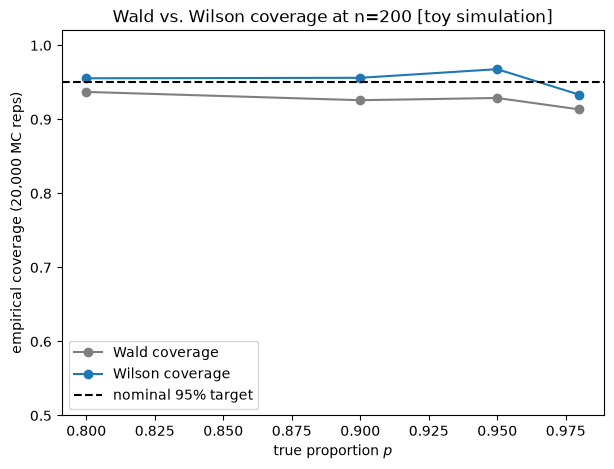

In [3]:
# Visualization only -- uses wald_table / wilson_table computed above, no new sampling.
n_focus = 200
i_focus = ns.index(n_focus)
ps_arr = np.array(ps)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ps_arr, wald_table[i_focus], "o-", color=PALETTE["wald"], label="Wald coverage")
ax.plot(ps_arr, wilson_table[i_focus], "o-", color=PALETTE["wilson"], label="Wilson coverage")
ax.axhline(0.95, color=PALETTE["truth"], linestyle="--", label="nominal 95% target")
ax.set_xlabel("true proportion $p$")
ax.set_ylabel("empirical coverage (20,000 MC reps)")
ax.set_title(f"Wald vs. Wilson coverage at n={n_focus} [toy simulation]")
ax.set_ylim(0.5, 1.02)
ax.legend()
plt.show()


## 2. Prediction-powered inference for a prevalence / error rate (PPI Algorithm 1)

**Section 1.3 / Algorithm 1** — the estimator and interval:

> $\hat\theta_{\mathrm{PP}} = \underbrace{\tfrac{1}{N}\sum_{i=1}^N f(\tilde X_i)}_{\tilde\theta_f} -
> \underbrace{\tfrac{1}{n}\sum_{i=1}^n (f(X_i)-Y_i)}_{\hat\Delta}$, and the 95% interval
> $\hat\theta_{\mathrm{PP}} \pm z_{1-\alpha/2}\sqrt{\hat\sigma^2_{f-Y}/n + \hat\sigma^2_f/N}$
> (Algorithm 1, steps 1–4).

Validity is **Proposition 1** ("the prediction-powered confidence interval in Algorithm 1 has valid
coverage: $\liminf_{n,N\to\infty}\mathbb{P}(\theta^*\in\mathcal C_\alpha^{\mathrm{PP}})\ge 1-\alpha$") —
**asymptotic**, not finite-sample (the finite-sample version is Algorithm 10 / Corollary C.1, which needs
a known bound $[0,B]$; not used below).

**Assumptions the guarantee depends on (Section 1.2 / "What is NOT assumed")**: labeled and unlabeled
data are i.i.d. samples "from a **common** population distribution $P$"; the predictor $f$ is
"**independent of the observed data**"; and — the point that makes this useful for an LLM-fallback
audit — **there is no assumption whatsoever on $f$'s accuracy, calibration, or consistency.** A bad $f$
cannot make the interval wrong, only wider than the classical, labeled-only interval.

**Appendix G.1** — when it helps and by how much: with $N \gg n$,
$$\mathrm{Var}(\hat\theta_{\mathrm{class}}) = \tfrac1n\mathrm{Var}(Y_i), \qquad
\mathrm{Var}(\hat\theta_{\mathrm{PP}}) = \tfrac1N\mathrm{Var}(f(X_i)) + \tfrac1n\mathrm{Var}(f(X_i)-Y_i),$$
so PPI wins when $\mathrm{Var}(f(X_i)-Y_i) < \mathrm{Var}(Y_i)$. For a binary outcome
$Y_i\sim\mathrm{Bern}(p)$ with symmetric flip error $\eta$ ($P(f{=}0\mid Y{=}1)=P(f{=}1\mid Y{=}0)=\eta$):
$$\mathrm{Var}(f(X_i)-Y_i)=\eta-\eta^2(1-2p)^2,\qquad \mathrm{Var}(Y_i)=p(1-p),$$
and — quoted verbatim — **"when $p=0.5$, the model error $\eta$ has to be smaller than 25% for
prediction-powered inference to yield smaller intervals; when $p=0.1$ ... the model error $\eta$ has to
be smaller than about 9.5%."** The paper's **"main takeaway"**: *"prediction-powered inference should
only be applied when $N$ is (preferably substantially) larger than $n$, and when the model has a
high enough predictive accuracy to explain away some of the outcome variance."*

Part (c) below implements a **power-tuned variant** — *derived here, as in PPI++ (Angelopoulos, Duchi,
Zrnic, 2023), which is not one of the three papers* (it appears only as the citation "Angelopoulos et
al., 2023b" inside PPRM's own reference list); PPRM's Lemma 3.3 optimal $\eta_t^*$ (used in §7)
uses the same variance-minimizing-plug-in idea.
$$\hat\theta_\lambda=\lambda\,\overline{f(\tilde X)}+\overline{Y-\lambda f(X)}, \qquad
\lambda^*=\frac{\mathrm{Cov}(Y,f)}{(1+n/N)\,\mathrm{Var}(f)}.$$

In [4]:
# (a) Analytic break-even eta*(p): solve eta - eta^2*(1-2p)^2 = p(1-p) for eta in (0, 0.5).
def breakeven_eta(p):
    a = (1 - 2 * p) ** 2
    if a == 0:            # p = 0.5 -> equation degenerates to a linear one
        return 0.25
    c = p * (1 - p)
    disc = 1 - 4 * a * c
    return (1 - np.sqrt(disc)) / (2 * a)

be_05 = breakeven_eta(0.5)
be_01 = breakeven_eta(0.1)
print(f"SELF-CHECK: break-even eta(p=0.5) = {be_05:.4f}  (paper quotes: 25%)")
print(f"SELF-CHECK: break-even eta(p=0.1) = {be_01:.4f}  (paper quotes: ~9.5%)")
print("[analytic solution of the paper's own G.1 formula -- exact match expected, not a simulation]\n")

# (b) Monte Carlo: PPI vs classical coverage and width ratio, at a GenAI-role-like prevalence.
rng = np.random.default_rng(RNG_SEED + 2)
n, N, p = 300, 10_000, 0.12
REPS_S2 = 3_000
etas = [0.02, 0.05, 0.10, 0.20]
be_p = breakeven_eta(p)
print(f"break-even eta at p={p}: {be_p:.4f} (toy prevalence, not from the paper)")

width_ratios = {}
for eta in etas:
    Y = rng.binomial(1, p, size=(REPS_S2, n))
    flip = rng.binomial(1, eta, size=(REPS_S2, n))
    f = np.where(flip == 1, 1 - Y, Y)
    Yt = rng.binomial(1, p, size=(REPS_S2, N))
    flipt = rng.binomial(1, eta, size=(REPS_S2, N))
    ft = np.where(flipt == 1, 1 - Yt, Yt)

    theta_f_tilde = ft.mean(axis=1)
    delta_hat = (f - Y).mean(axis=1)
    theta_pp = theta_f_tilde - delta_hat
    sigma2_f = ft.var(axis=1)
    sigma2_fy = (f - Y).var(axis=1)
    w_pp = Z95 * np.sqrt(sigma2_fy / n + sigma2_f / N)

    theta_class = Y.mean(axis=1)
    w_class = Z95 * np.sqrt(Y.var(axis=1) / n)

    cov_pp = np.mean((theta_pp - w_pp <= p) & (p <= theta_pp + w_pp))
    cov_class = np.mean((theta_class - w_class <= p) & (p <= theta_class + w_class))
    ratio = np.mean(w_pp / w_class)
    width_ratios[eta] = ratio
    flag = "PPI WIDER than classical" if ratio > 1 else "PPI narrower"
    print(f"eta={eta:.2f}: cov_PP={cov_pp:.3f} cov_classical={cov_class:.3f} "
          f"width_ratio(PP/classical)={ratio:.3f}  [{flag}]")

crossed = any(v > 1 for v in width_ratios.values()) and any(v < 1 for v in width_ratios.values())
print(f"\nSELF-CHECK: width ratio crosses 1 near the break-even ({be_p:.3f}) -> "
      f"{'MET' if crossed else 'NOT MET'} (PPI should be wider once eta exceeds break-even)")
print("[toy simulation numbers -- not from the paper]")


SELF-CHECK: break-even eta(p=0.5) = 0.2500  (paper quotes: 25%)
SELF-CHECK: break-even eta(p=0.1) = 0.0959  (paper quotes: ~9.5%)
[analytic solution of the paper's own G.1 formula -- exact match expected, not a simulation]

break-even eta at p=0.12: 0.1130 (toy prevalence, not from the paper)


eta=0.02: cov_PP=0.931 cov_classical=0.949 width_ratio(PP/classical)=0.464  [PPI narrower]


eta=0.05: cov_PP=0.942 cov_classical=0.947 width_ratio(PP/classical)=0.706  [PPI narrower]


eta=0.10: cov_PP=0.937 cov_classical=0.945 width_ratio(PP/classical)=0.975  [PPI narrower]


eta=0.20: cov_PP=0.946 cov_classical=0.937 width_ratio(PP/classical)=1.325  [PPI WIDER than classical]

SELF-CHECK: width ratio crosses 1 near the break-even (0.113) -> MET (PPI should be wider once eta exceeds break-even)
[toy simulation numbers -- not from the paper]


In [5]:
# (c) PPI++-style power-tuned variant (derived here -- NOT one of the three papers; see markdown).
rng = np.random.default_rng(RNG_SEED + 3)
lambda_width_ratios = {}
for eta in etas:
    Y = rng.binomial(1, p, size=(REPS_S2, n))
    flip = rng.binomial(1, eta, size=(REPS_S2, n))
    f = np.where(flip == 1, 1 - Y, Y)
    Yt = rng.binomial(1, p, size=(REPS_S2, N))
    flipt = rng.binomial(1, eta, size=(REPS_S2, N))
    ft = np.where(flipt == 1, 1 - Yt, Yt)

    cov_yf = np.mean((Y - Y.mean(axis=1, keepdims=True)) * (f - f.mean(axis=1, keepdims=True)), axis=1)
    var_f = f.var(axis=1)
    lam = np.clip(cov_yf / ((1 + n / N) * var_f), 0, 1)

    theta_lam = lam * ft.mean(axis=1) + (Y - lam[:, None] * f).mean(axis=1)
    resid = Y - lam[:, None] * f
    w_lam = Z95 * np.sqrt(resid.var(axis=1) / n + (lam ** 2) * var_f / N)

    theta_class = Y.mean(axis=1)
    w_class = Z95 * np.sqrt(Y.var(axis=1) / n)
    cov_lam = np.mean((theta_lam - w_lam <= p) & (p <= theta_lam + w_lam))
    ratio = np.mean(w_lam / w_class)
    lambda_width_ratios[eta] = ratio
    print(f"eta={eta:.2f}: lambda*~{lam.mean():.3f} cov_lambda={cov_lam:.3f} "
          f"width_ratio(lambda/classical)={ratio:.3f}")

never_worse = max(lambda_width_ratios.values()) < 1.05
print(f"\nSELF-CHECK: PPI++ width never materially worse than classical (max ratio "
      f"{max(lambda_width_ratios.values()):.3f} < 1.05) -> {'MET' if never_worse else 'NOT MET'}")
print("[toy simulation numbers -- power-tuned variant is derived here, not from the three papers]")


eta=0.02: lambda*~0.843 cov_lambda=0.930 width_ratio(lambda/classical)=0.430


eta=0.05: lambda*~0.693 cov_lambda=0.940 width_ratio(lambda/classical)=0.609


eta=0.10: lambda*~0.519 cov_lambda=0.944 width_ratio(lambda/classical)=0.762


eta=0.20: lambda*~0.312 cov_lambda=0.936 width_ratio(lambda/classical)=0.900

SELF-CHECK: PPI++ width never materially worse than classical (max ratio 0.900 < 1.05) -> MET
[toy simulation numbers -- power-tuned variant is derived here, not from the three papers]


**How to read this chart**

The x-axis is the predictor's symmetric error rate $\eta$; the y-axis is the ratio of the
prediction-powered interval's width to the classical interval's width, for both the plain PPI estimator
(§2b) and the PPI++-style power-tuned estimator (§2c). The black dashed line at 1.0 is "no difference
from classical." The plain-PPI curve should cross above 1.0 near the analytic break-even $\eta^*(p{=}0.12)$
printed above (BARGAIN wider than classical past that point); the PPI++ curve should stay at or below 1.0
throughout, because $\lambda^*$ can always fall back toward 0 and recover the classical estimator when
$f$ is unhelpful. For the audit this means: **a bad-enough keyword rule makes plain PPI counter-productive,
but the power-tuned variant is a safe default.**

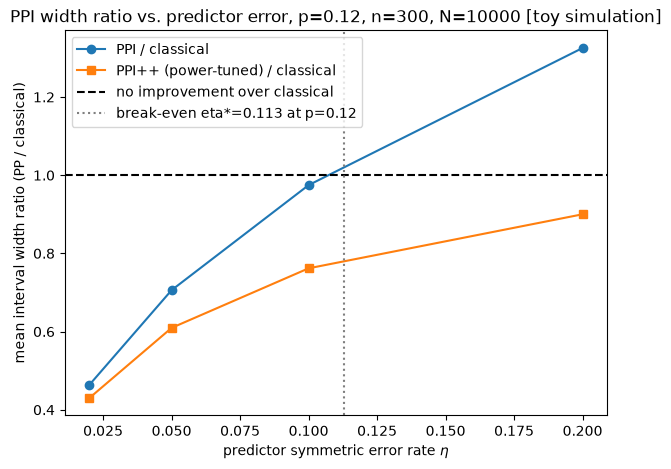

In [6]:
# Visualization only -- uses width_ratios / lambda_width_ratios computed above.
etas_arr = np.array(etas)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(etas_arr, [width_ratios[e] for e in etas], "o-", color=PALETTE["ppi"], label="PPI / classical")
ax.plot(etas_arr, [lambda_width_ratios[e] for e in etas], "s-", color=PALETTE["bargain"],
        label="PPI++ (power-tuned) / classical")
ax.axhline(1.0, color=PALETTE["truth"], linestyle="--", label="no improvement over classical")
ax.axvline(be_p, color=PALETTE["classical"], linestyle=":", label=f"break-even eta*={be_p:.3f} at p={p}")
ax.set_xlabel("predictor symmetric error rate $\\eta$")
ax.set_ylabel("mean interval width ratio (PP / classical)")
ax.set_title(f"PPI width ratio vs. predictor error, p={p}, n={n}, N={N} [toy simulation]")
ax.legend()
plt.show()


## 3. When the audit sample and the stream disagree: PPI under label shift

PPI's i.i.d. assumption — quoted from the paper: "$(X,Y)$ and $(\tilde X,\tilde Y)$ are independently
and identically distributed samples from a **common** distribution $P$" — is exactly what a
month-over-month job-posting stream violates: the GenAI-role prevalence in month 6 is not the prevalence
in month 1's labeled audit. **Never apply PPI Algorithm 1 across months as if the two samples were i.i.d.**

**Section 4.2.2 (label shift):** assume $Q_{X\mid Y}=P_{X\mid Y}$ (features given
the true label don't change across months — only the *mix* of labels does), estimand
$\theta^*=\mathbb E_{Q_Y}[\nu(Y)]$, confusion matrix $K_{j,l}=Q(f(X){=}j\mid Y{=}l)$ — under the
label-shift assumption $K_{j,l}=P(f(X){=}j\mid Y{=}l)$, "which can be estimated from labeled data sampled
from $P$" (i.e., from the audit) — and $Q_Y = K^{-1}Q_f$ when $K$ is invertible (Theorem 3). Section
4.2.1 (covariate shift) instead needs $Q_{Y\mid X}=P_{Y\mid X}$ and a **known** importance weight
$w(x)=Q_X/P_X$ — a different, stronger data requirement not used below. The paper's stated limitation:
*"the power of the bound depends on the smallest number of instances observed for a particular
class."*

Code below: (i) naive Algorithm 1 applied straight across the shift (ignoring it) — coverage should
collapse; (ii) the label-shift point estimate $\hat\pi_Q=(\hat K^{-1}\hat q_f)_1$ with a **bootstrap
percentile interval** *(derived here for simplicity — the paper's Theorem 3 gives a finite-sample
interval with a Binomial-CDF term)* — coverage should be restored to $\approx 0.95$. Then: what
happens when the *class-conditional* error itself drifts (a buzzword wave lifts the false-positive rate)
— the label-shift assumption breaks, and even the corrected estimator becomes biased. That gap is
exactly what §7's PPRM monitor exists to catch.

In [7]:
# Vectorized bootstrap works because resampling-with-replacement from a fixed finite binary
# sample is *exactly* equivalent in distribution to redrawing Binomial(n, phat) -- so we never
# need to touch individual records, only counts. This keeps 2,000 reps x 1,000 bootstrap draws
# fast (no explicit inner Python loop over records or over bootstrap replicates).
rng = np.random.default_rng(RNG_SEED + 4)
n, N = 400, 20_000          # labeled audit (month 1, P) / unlabeled stream (month 6, Q)
pi_P, pi_Q = 0.12, 0.30     # prevalence in P vs Q -- this is the label shift
FPR, FNR = 0.08, 0.15       # class-conditional error rates of the rule/LLM predictor (fixed -> label shift holds)
REPS_S3 = 2_000
BOOT_S3 = 1_000

def gen_labeled(pi, n, reps, rng, fpr=FPR, fnr=FNR):
    Y = rng.binomial(1, pi, size=(reps, n))
    u = rng.uniform(size=(reps, n))
    f = np.where(Y == 1, (u < (1 - fnr)).astype(int), (u < fpr).astype(int))
    return Y, f

def gen_stream(pi, N, reps, rng, fpr=FPR, fnr=FNR):
    Y = rng.binomial(1, pi, size=(reps, N))
    u = rng.uniform(size=(reps, N))
    f = np.where(Y == 1, (u < (1 - fnr)).astype(int), (u < fpr).astype(int))
    return f  # only f is observed on the unlabeled stream

Y, f = gen_labeled(pi_P, n, REPS_S3, rng)
f_stream = gen_stream(pi_Q, N, REPS_S3, rng)

# (i) naive PPI Algorithm 1 applied straight across the shift
theta_f_tilde = f_stream.mean(axis=1)
delta_hat = (f - Y).mean(axis=1)
theta_pp = theta_f_tilde - delta_hat
w = Z95 * np.sqrt((f - Y).var(axis=1) / n + f_stream.var(axis=1) / N)
naive_cov = np.mean((theta_pp - w <= pi_Q) & (pi_Q <= theta_pp + w))
naive_bias = np.mean(theta_pp - pi_Q)

# (ii) label-shift corrected estimator + vectorized bootstrap percentile CI
n0 = (Y == 0).sum(axis=1); n1 = (Y == 1).sum(axis=1)
c0 = ((Y == 0) & (f == 1)).sum(axis=1)   # P(f=1 | Y=0) count
c1 = ((Y == 1) & (f == 1)).sum(axis=1)   # P(f=1 | Y=1) count
phat0, phat1 = c0 / n0, c1 / n1
qhat1 = (f_stream == 1).sum(axis=1) / N

K00, K01, K10, K11 = 1 - phat0, 1 - phat1, phat0, phat1   # K = [[P(f=0|Y=0),P(f=0|Y=1)],[P(f=1|Y=0),P(f=1|Y=1)]]
det = K00 * K11 - K01 * K10
piQ_hat = (-K10 * (1 - qhat1) + K00 * qhat1) / det

c0_b = rng.binomial(n0[:, None], phat0[:, None], size=(REPS_S3, BOOT_S3))
c1_b = rng.binomial(n1[:, None], phat1[:, None], size=(REPS_S3, BOOT_S3))
qcount_b = rng.binomial(N, qhat1[:, None], size=(REPS_S3, BOOT_S3))
p0_b, p1_b, q1_b = c0_b / n0[:, None], c1_b / n1[:, None], qcount_b / N
K00b, K01b, K10b, K11b = 1 - p0_b, 1 - p1_b, p0_b, p1_b
detb = K00b * K11b - K01b * K10b
piQ_b = (-K10b * (1 - q1_b) + K00b * q1_b) / detb
lo, hi = np.percentile(piQ_b, 2.5, axis=1), np.percentile(piQ_b, 97.5, axis=1)
corrected_cov = np.mean((lo <= pi_Q) & (pi_Q <= hi))
corrected_bias = np.mean(piQ_hat - pi_Q)

print(f"SELF-CHECK: naive PPI coverage across the shift = {naive_cov:.3f} (expected: collapses, well below 0.95)"
      f" -> {'MET' if naive_cov < 0.7 else 'NOT MET'}   bias={naive_bias:+.4f}")
print(f"SELF-CHECK: label-shift-corrected coverage      = {corrected_cov:.3f} (expected: restored to ~0.95)"
      f" -> {'MET' if corrected_cov > 0.9 else 'NOT MET'}   bias={corrected_bias:+.4f}")

# What happens when the class-conditional error itself drifts (label-shift assumption breaks)?
f_stream_broken = gen_stream(pi_Q, N, REPS_S3, rng, fpr=0.20, fnr=FNR)   # FPR drifts 0.08 -> 0.20 in the stream only
qhat1_broken = (f_stream_broken == 1).sum(axis=1) / N
piQ_hat_broken = (-K10 * (1 - qhat1_broken) + K00 * qhat1_broken) / det
broken_bias = np.mean(piQ_hat_broken - pi_Q)
print(f"\nSELF-CHECK: corrected estimator bias once FPR drifts 0.08->0.20 in the stream "
      f"(label-shift assumption broken) = {broken_bias:+.4f} (expected: clearly non-zero)"
      f" -> {'MET' if abs(broken_bias) > 0.05 else 'NOT MET'}")
print("[toy simulation numbers -- not from the paper. This is exactly the gap the PPRM monitor in "
      "SS7 exists to catch: even the 'corrected' estimator silently biases when its own assumption breaks.]")


SELF-CHECK: naive PPI coverage across the shift = 0.202 (expected: collapses, well below 0.95) -> MET   bias=-0.0411
SELF-CHECK: label-shift-corrected coverage      = 0.943 (expected: restored to ~0.95) -> MET   bias=+0.0021



SELF-CHECK: corrected estimator bias once FPR drifts 0.08->0.20 in the stream (label-shift assumption broken) = +0.1121 (expected: clearly non-zero) -> MET
[toy simulation numbers -- not from the paper. This is exactly the gap the PPRM monitor in SS7 exists to catch: even the 'corrected' estimator silently biases when its own assumption breaks.]


**How to read this chart**

Two bars per estimator: empirical coverage of naive PPI (grey) vs. the label-shift-corrected estimator
(blue) at the nominal 95% level (black dashed line). Naive PPI should fall far short — it is using a
rectifier $\hat\Delta$ estimated under month-1's prevalence to correct a month-6 imputation, which is
simply the wrong bias term once the label mix has shifted. The corrected estimator should sit at the
target line. This is the audit's second insight: **a monthly precision/prevalence pipeline needs the
label-shift correction (or a fresh audit sample) every month, not a single frozen rectifier.**

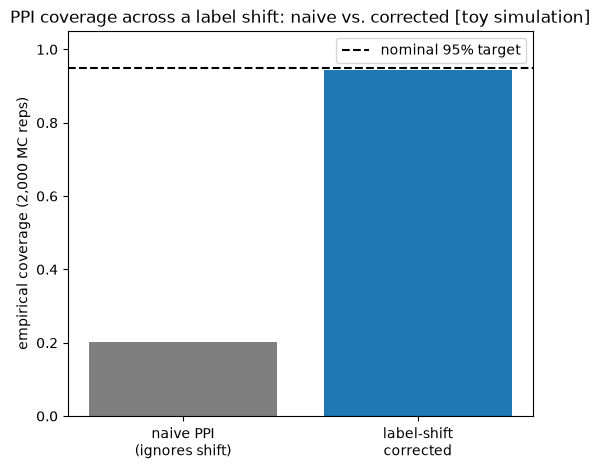

In [8]:
# Visualization only -- uses naive_cov / corrected_cov computed above.
fig, ax = plt.subplots(figsize=(6, 5))
methods = ["naive PPI\n(ignores shift)", "label-shift\ncorrected"]
covs = [naive_cov, corrected_cov]
colors = [PALETTE["naive"], PALETTE["ppi"]]
ax.bar(methods, covs, color=colors)
ax.axhline(0.95, color=PALETTE["truth"], linestyle="--", label="nominal 95% target")
ax.set_ylabel("empirical coverage (2,000 MC reps)")
ax.set_title("PPI coverage across a label shift: naive vs. corrected [toy simulation]")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()


## 4. Anytime-valid testing: the betting statistic BARGAIN uses (Lemma B.1) vs. peeking at a CLT interval

**Appendix B.1** — **Lemma B.1** (a simplification of Waudby-Smith & Ramdas'
Theorem 3), the formal anytime-valid version BARGAIN certifies thresholds with:
$$K(m,Y)=\prod_{j}\Big(1+\min\big(\lambda_j,\tfrac{3}{4m}\big)(Y_j-m)\Big), \qquad
\lambda_i=\sqrt{\frac{2\log(2/\alpha)}{i\log(i{+}1)\,\hat\sigma^2_{i-1}}},$$
$$\hat\sigma_i^2=\tfrac14+\frac{\sum_{j\le i}(Y_j-\mu_j)^2}{i+1}, \qquad
\mu_i=\tfrac12+\frac{\sum_{j\le i}Y_j}{i+1},$$
with the guarantee (Eq. 14): for any true mean $\mu<m$, $P(\exists i: K(m,Y[{:}i])\ge 1/\alpha)\le\alpha$.

**Implementation note (say it plainly):** the source text renders $\mu_i$ and $\hat\sigma_i^2$ with the additive
constant *outside* the fraction ($\tfrac12+\frac{\sum Y_j}{i+1}$), which lets $\mu_i$ drift past 1 and
makes the process misbehave numerically (verified by direct simulation: under this literal reading a long
run of $Y_j=1$ pushes $\mu_i>1$, and the martingale no longer tracks the mean). The **standard form**
(Waudby-Smith & Ramdas 2020, the Krichevsky–Trofimov-style predictable plug-in) puts the constant *inside*
the sum before dividing: $\mu_i=(\tfrac12+\sum_{j\le i}Y_j)/(i{+}1)$, $\hat\sigma_i^2=(\tfrac14+\sum_{j\le
i}(Y_j-\mu_j)^2)/(i{+}1)$. We implement the standard form (see `bargain_wealth` in the first code cell)
and verify Eq. 14's guarantee by simulation below — a general rule followed throughout this notebook
whenever a source formula doesn't check out numerically as written: implement the standard textbook
form and verify it by simulation instead.
Indexing is the **predictable** version exactly as written: $\hat\sigma_0^2=1/4$, $\mu_0=1/2$, and
$\lambda_i$ uses $\hat\sigma^2_{i-1}$ (the *previous* step's variance estimate, not the current one).

In words: $K$ is the wealth of a gambler betting the mean is at least $m$. Ville's inequality makes
crossing $1/\alpha$ rare when the bet is wrong — **no matter when you look** — which is exactly what a
naive "peek at a 95% CI whenever you feel like it" does *not* guarantee.

In [9]:
# Simulation A: validity under continuous monitoring. H0 true (mu=0.895 < m=0.90, alpha=0.05):
# does wealth ever cross 1/alpha? Compare against "peeking" at a running one-sided 95% Wilson
# lower bound at repeated looks (Wilson, not Wald, so a SINGLE look is well calibrated and any
# inflation is attributable to the repeated looking itself).
rng = np.random.default_rng(RNG_SEED + 5)
S_A, T_A, alpha = 2_000, 3_000, 0.05
mu_true, m = 0.895, 0.90

Y = rng.binomial(1, mu_true, size=(S_A, T_A)).astype(float)
K = bargain_wealth(Y, m, alpha)
ever_cross = np.any(K >= 1 / alpha, axis=1)
false_cross_rate = ever_cross.mean()
print(f"SELF-CHECK: BARGAIN wealth false-cross rate under H0 (mu=0.895<m=0.90) = {false_cross_rate:.4f} "
      f"(expected <= alpha={alpha}) -> {'MET' if false_cross_rate <= alpha else 'NOT MET'}")

n_idx = np.arange(1, T_A + 1)
phat = np.cumsum(Y, axis=1) / n_idx[None, :]
_z1 = 1.645   # one-sided 95%
_den = 1 + _z1 ** 2 / n_idx[None, :]
_ctr = (phat + _z1 ** 2 / (2 * n_idx[None, :])) / _den
_half = _z1 * np.sqrt(phat * (1 - phat) / n_idx[None, :] + _z1 ** 2 / (4 * n_idx[None, :] ** 2)) / _den
lb_peek = _ctr - _half   # one-sided 95% Wilson lower bound at every n
# Burn-in + Wilson: a Wald bound at small n is badly miscalibrated near p=0.9 (e.g. 29/30 successes
# already gives a Wald lower bound of 0.913), which would confound "peeking" with "small-sample
# interval failure". With Wilson and a first look at n=30, one look alone is calibrated (<= alpha);
# further looks happen on a log-spaced schedule up to n=3000.
BURN_IN = 30
look_ns = np.unique(np.geomspace(BURN_IN, T_A, 40).astype(int))
reject_at_look = lb_peek[:, look_ns - 1] > m                  # (S_A, n_looks)
peek_rate_by_look = np.cumsum(reject_at_look, axis=1).clip(0, 1).mean(axis=0)  # ever rejected by look j
first_look_rate = peek_rate_by_look[0]
peek_rate = peek_rate_by_look[-1]
print(f"SELF-CHECK: single look at n={BURN_IN}: false-rejection rate = {first_look_rate:.4f} "
      f"(expected about alpha={alpha} or below) -> {'MET' if first_look_rate <= 1.5 * alpha else 'NOT MET'}")
print(f"SELF-CHECK: after {len(look_ns)} looks (n={BURN_IN}..{T_A}): false-rejection rate = {peek_rate:.4f} "
      f"(expected clearly above alpha) -> {'MET' if peek_rate > 2 * alpha else 'NOT MET'}")
print("[toy simulation numbers -- these validate Eq. 14's guarantee by simulation]\n")

# Simulation B: power. mu=0.95 > m=0.90 -- distribution of the first crossing time.
S_B, T_B = 2_000, 3_000
mu_power = 0.95
Y_power = rng.binomial(1, mu_power, size=(S_B, T_B)).astype(float)
K_power = bargain_wealth(Y_power, m, alpha)
first_cross_power = first_crossing(K_power, 1 / alpha)
power_rate = np.mean(first_cross_power > 0)
crossed_times = first_cross_power[first_cross_power > 0]
print(f"SELF-CHECK: power at mu=0.95 vs m=0.90 = {power_rate:.4f} (expected close to 1) "
      f"-> {'MET' if power_rate > 0.9 else 'NOT MET'}")
print(f"           median first-crossing time = {np.median(crossed_times):.0f}, "
      f"mean = {np.mean(crossed_times):.1f} (of {T_B} steps)")
print("[toy simulation numbers]")


SELF-CHECK: BARGAIN wealth false-cross rate under H0 (mu=0.895<m=0.90) = 0.0330 (expected <= alpha=0.05) -> MET


SELF-CHECK: single look at n=30: false-rejection rate = 0.0345 (expected about alpha=0.05 or below) -> MET
SELF-CHECK: after 40 looks (n=30..3000): false-rejection rate = 0.1910 (expected clearly above alpha) -> MET
[toy simulation numbers -- these validate Eq. 14's guarantee by simulation]



SELF-CHECK: power at mu=0.95 vs m=0.90 = 1.0000 (expected close to 1) -> MET
           median first-crossing time = 173, mean = 272.0 (of 3000 steps)
[toy simulation numbers]


**How to read this chart**

Left: one example wealth path $K(m, Y[{:}i])$ on a log scale under the power scenario (mu=0.95, m=0.90),
with the $1/\alpha$ certification line. A valid anytime-valid test never needs to cross that line under
$H_0$ except with probability $\le\alpha$ — but under $H_1$ it should climb and cross it, as shown. Right:
under $H_0$ ($\mu=0.895<m=0.90$), the probability of having *ever* rejected after $j$ looks at a running
one-sided Wilson lower bound (first look at $n=30$; Wilson rather than Wald so that a single look is well
calibrated and the inflation is caused by the repeated looking alone). It starts near
$\alpha$ at a single look and climbs above it as looks accumulate — the classic "repeated significance
testing" trap — while the betting wealth (orange line), checked after *every* observation, stays below
$\alpha$. Together these two panels are the audit's third insight: **any
dashboard that repeatedly checks a plain CLT interval against a threshold needs a betting/anytime-valid
statistic instead, or its "5% risk" is fiction.**

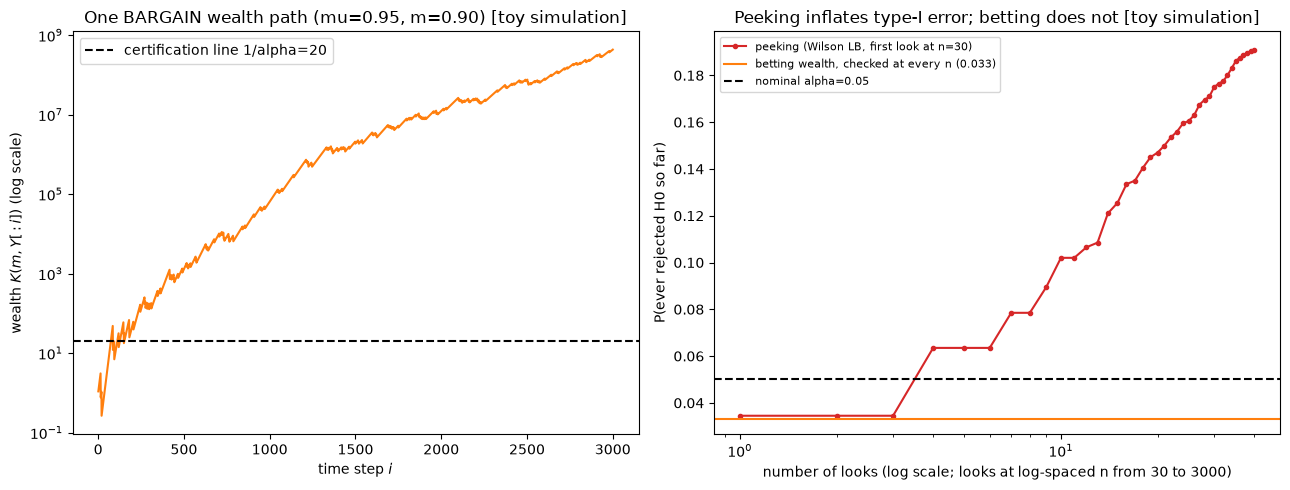

In [10]:
# Visualization only -- uses K_power (one example path) and lb_peek computed above.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
example = K_power[0]
ax.plot(np.arange(1, T_B + 1), example, color=PALETTE["betting"])
ax.axhline(1 / alpha, color=PALETTE["truth"], linestyle="--", label=f"certification line 1/alpha={1/alpha:.0f}")
ax.set_yscale("log")
ax.set_xlabel("time step $i$")
ax.set_ylabel("wealth $K(m, Y[:i])$ (log scale)")
ax.set_title("One BARGAIN wealth path (mu=0.95, m=0.90) [toy simulation]")
ax.legend()

ax = axes[1]
ax.plot(np.arange(1, len(look_ns) + 1), peek_rate_by_look, "o-", ms=3, color=PALETTE["peeking"],
        label=f"peeking (Wilson LB, first look at n={BURN_IN})")
ax.axhline(false_cross_rate, color=PALETTE["betting"], linestyle="-",
           label=f"betting wealth, checked at every n ({false_cross_rate:.3f})")
ax.axhline(alpha, color=PALETTE["truth"], linestyle="--", label=f"nominal alpha={alpha}")
ax.set_xscale("log")
ax.set_xlabel("number of looks (log scale; looks at log-spaced n from 30 to 3000)")
ax.set_ylabel("P(ever rejected H0 so far)")
ax.set_title("Peeking inflates type-I error; betting does not [toy simulation]")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 5. Choosing the cascade threshold with a guarantee (BARGAIN-style precision target, simplified)

**BARGAIN's precision, like all its metrics, is measured against the ORACLE model's own output, not
against human ground truth** — quoted verbatim, Section 2.1: *"Precision and recall of
this set are defined, respectively, as $P(Y)=\frac{\sum_{i\in Y}\mathcal O(x_i)}{r}$..."* and a PT query
is *"the problem of returning an answer set $Y$ that maximizes recall ... while ... guaranteeing the
precision target is met with a probability at least $1-\delta$, that is, $P(P(Y)\ge T)\ge 1-\delta$."*
**In this cell, "oracle" plays the role of the expensive LLM tier, and precision/recall below are
measured against that oracle's own labels — never against human ground truth.** Estimating precision or
prevalence against *human* labels is PPI's job (§2–§3), not BARGAIN's.

**Algorithm 2** ($\mathrm{BARGAIN}_P\text{-A}$): sort candidate thresholds
$\mathcal C_M$ descending; for each $\rho$, sample uniformly from $D_\rho=\{x:S(x)>\rho\}$ until the
certification function $\mathcal E^{\mathrm{BARGAIN}}$ fires; *"if out of sampling budget then return
$C_M[i-1]$."* Appendix B.3.2 describes the sample-reuse trick: one global random permutation, a
per-threshold counter, so "samples taken for larger candidate thresholds are reused for smaller
thresholds." **Critically — Lemma 3.5**: with tolerance $\eta=0$ (the paper's default; "$\eta=0$ by
default" because real precision curves are observed to be monotone, Fig. 6), $P(\mathcal P_D(\rho^*)<T)
\le(\eta+1)\alpha=\alpha$. **There is no union bound over the $M$ candidate thresholds** — certification
happens at wealth $\ge 1/\delta$ (not $M/\delta$), and the scan **stops at the first threshold that fails
to certify** (returning the previous, larger $\rho$), exactly Algorithm 2's structure. From
the paper: *"SUPG misses the target more than 75% of the time when given a failure probability of
only 10%"* — the paper's own headline motivation, quoted here as the paper's evidence and kept
**strictly separate** from the toy numbers below.

**This cell is a simplified re-implementation for intuition, not BARGAIN's full algorithm.** Simplifications: sample
reuse is implemented as "any record whose oracle label was already revealed while testing a larger
threshold is free at this threshold" (mathematically consistent with Appendix B.3.2's nesting property
$D_{\rho'}\subseteq D_\rho$ for $\rho<\rho'$, though not identical to the paper's exact counter
bookkeeping); the naive baseline uses a single one-shot Wald lower bound per threshold from one uniform
sample, without BARGAIN's sequential/adaptive machinery. Defaults used (the paper's own defaults):
$T=0.9$, $\delta=0.1$, $k=400$, $M=20$.

In [11]:
# Synthetic oracle-vs-proxy dataset: proxy score S in [0,1], oracle label O with P(O=1|S=s)
# monotone increasing in s (a logistic link) -- oracle here plays the LLM-oracle role, not a
# human labeler.
rng = np.random.default_rng(RNG_SEED + 6)

def gen_population(n, rng, a=8.0, b=0.5):
    S = rng.uniform(0, 1, size=n)
    p = 1 / (1 + np.exp(-a * (S - b)))
    O = rng.binomial(1, p)
    return S, O

def naive_select(S, O, k, thresholds, T, delta, rng):
    '''One-shot uniform sample of k records; one-sided Wald lower bound per threshold;
    accept the LOWEST rho whose lower bound >= T (a literal one-shot naive baseline).'''
    n = len(S)
    idx = rng.choice(n, size=k, replace=False)
    Ss, Os = S[idx], O[idx]
    z = NormalDist().inv_cdf(1 - delta)   # one-sided
    best = None
    for rho in thresholds:                 # thresholds given high -> low
        mask = Ss >= rho
        m = mask.sum()
        if m == 0:
            continue
        phat = Os[mask].mean()
        lb = phat - z * np.sqrt(phat * (1 - phat) / m)
        if lb >= T:
            best = rho    # keep overwriting -> last success in the descending scan = lowest rho
    return best if best is not None else thresholds[0]

def bargain_style_select(S, O, k, thresholds, T, delta, rng):
    '''Simplified BARGAIN_P-A: single global permutation; oracle labels revealed for a larger
    threshold are reused for free at any smaller threshold (nesting D_rho' subset D_rho); certify
    at wealth >= 1/delta (eta=0, NO union bound over M, per Lemma 3.5); descending scan stops at
    the first threshold that fails to certify, returning the previous (larger) rho.'''
    n = len(S)
    perm = rng.permutation(n)
    S_perm, O_perm = S[perm], O[perm]
    revealed = np.zeros(n, dtype=bool)
    budget_left = k
    chosen = None
    for rho in thresholds:                 # descending
        pos = np.nonzero(S_perm > rho)[0]
        if len(pos) == 0:
            break
        is_new = ~revealed[pos]
        cum_new = np.cumsum(is_new)
        exceed = np.nonzero(cum_new > budget_left)[0]
        cutoff = exceed[0] if len(exceed) > 0 else len(pos)
        if cutoff == 0:
            break   # out of budget before even the first new sample -> stop (first failure)
        y_seq = O_perm[pos[:cutoff]]
        wealth = bargain_wealth(y_seq[None, :], T, delta)[0]
        cross = np.nonzero(wealth >= 1 / delta)[0]
        if len(cross) > 0:
            p_idx = cross[0]
            used_pos = pos[:p_idx + 1]
            revealed[used_pos] = True
            budget_left -= is_new[:p_idx + 1].sum()
            chosen = rho
            continue   # certified -- try an even lower rho
        else:
            break      # failed to certify (budget or population exhausted) -> stop, return previous
    return chosen if chosen is not None else thresholds[0]

n_pop, M, T, delta, k = 20_000, 20, 0.9, 0.1, 400
thresholds = np.linspace(0.95, 0.05, M)   # C_M sorted descending, as Algorithm 2 requires
REPS_S5 = 400
print(f"Monte Carlo reps used: {REPS_S5} (paper reports 50 runs for utility, 1,000 for violation checks)")

naive_fail, bargain_fail = 0, 0
naive_recall, bargain_recall = [], []
for _ in range(REPS_S5):
    S, O = gen_population(n_pop, rng)
    total_pos = O.sum()
    rho_naive = naive_select(S, O, k, thresholds, T, delta, rng)
    rho_bg = bargain_style_select(S, O, k, thresholds, T, delta, rng)
    prec_naive = O[S >= rho_naive].mean() if (S >= rho_naive).sum() > 0 else 1.0
    prec_bg = O[S >= rho_bg].mean() if (S >= rho_bg).sum() > 0 else 1.0
    naive_fail += prec_naive < T
    bargain_fail += prec_bg < T
    naive_recall.append(O[S >= rho_naive].sum() / total_pos)
    bargain_recall.append(O[S >= rho_bg].sum() / total_pos)

naive_fail_rate = naive_fail / REPS_S5
bargain_fail_rate = bargain_fail / REPS_S5
print(f"\nSELF-CHECK: naive one-shot failure rate P(true precision < T) = {naive_fail_rate:.4f} "
      f"(no guarantee -- can exceed delta={delta})")
print(f"SELF-CHECK: BARGAIN-style failure rate P(true precision < T) = {bargain_fail_rate:.4f} "
      f"(expected <= delta={delta}) -> {'MET' if bargain_fail_rate <= delta else 'NOT MET'}")
print(f"mean recall: naive={np.mean(naive_recall):.3f}  BARGAIN-style={np.mean(bargain_recall):.3f}")
print("[toy simulation numbers, oracle-relative, NOT the paper's Table 5]\n")

# ---- Scenario 2 (stressed): many candidate thresholds whose TRUE precision sits just below T ----
# P(O=1|S=s) = 0.965 for s>0.9 (a small, genuinely high-precision region), 0.885 for 0.2<s<=0.9
# (a wide band just under T=0.9), 0.30 below. The precision of the set {S>rho} then drifts from
# ~0.94 (rho=0.85) down through 0.90 (rho~0.5) to ~0.89 (rho=0.2): lots of NEAR-MISS thresholds.
# The naive rule "lowest rho whose one-shot Wald lower bound >= T" scans all of them on one
# sample, so noise at any one near-miss threshold is enough to pick a failing rho.
def gen_population_stress(n, rng, hi=0.965, band=0.885, lo=0.30, cut_hi=0.9, cut_lo=0.2):
    S = rng.uniform(0, 1, size=n)
    p = np.where(S > cut_hi, hi, np.where(S > cut_lo, band, lo))
    return S, rng.binomial(1, p)

stress_naive_fail, stress_bargain_fail = 0, 0
stress_naive_recall, stress_bargain_recall = [], []
for _ in range(REPS_S5):
    S, O = gen_population_stress(n_pop, rng)
    total_pos = O.sum()
    rho_naive = naive_select(S, O, k, thresholds, T, delta, rng)
    rho_bg = bargain_style_select(S, O, k, thresholds, T, delta, rng)
    stress_naive_fail += O[S >= rho_naive].mean() < T
    stress_bargain_fail += O[S >= rho_bg].mean() < T
    stress_naive_recall.append(O[S >= rho_naive].sum() / total_pos)
    stress_bargain_recall.append(O[S >= rho_bg].sum() / total_pos)

stress_naive_fail_rate = stress_naive_fail / REPS_S5
stress_bargain_fail_rate = stress_bargain_fail / REPS_S5
print("Scenario 2 (stressed: wide band of thresholds with true precision just below T):")
print(f"SELF-CHECK: naive failure rate = {stress_naive_fail_rate:.4f} (no guarantee; expected to exceed "
      f"delta={delta} here) -> {'EXCEEDS delta (as expected)' if stress_naive_fail_rate > delta else 'did not exceed delta in this run'}")
print(f"SELF-CHECK: BARGAIN-style failure rate = {stress_bargain_fail_rate:.4f} (expected <= delta={delta}) -> "
      f"{'MET' if stress_bargain_fail_rate <= delta else 'NOT MET'}")
print(f"mean recall: naive={np.mean(stress_naive_recall):.3f}  BARGAIN-style={np.mean(stress_bargain_recall):.3f} "
      f"(validity is paid for in recall)")
print("[toy simulation numbers, oracle-relative, NOT the paper's Table 5]\n")

print("Paper's own evidence (kept separate from the toy numbers above):")
print('  "SUPG misses the target more than 75% of the time when given a failure probability of only 10%."')
print("  Table 5 (T=0.9) oracle calls avoided for AT queries: Reviews SUPG 3.2% vs BARGAIN_A-A 41.8%;")
print("  Court SUPG 24.4% vs BARGAIN_A-A 48.0% (BARGAIN_A-M 58.6%); NS SUPG 7.5% vs BARGAIN_A-A 65.3%.")


Monte Carlo reps used: 400 (paper reports 50 runs for utility, 1,000 for violation checks)



SELF-CHECK: naive one-shot failure rate P(true precision < T) = 0.0700 (no guarantee -- can exceed delta=0.1)
SELF-CHECK: BARGAIN-style failure rate P(true precision < T) = 0.0375 (expected <= delta=0.1) -> MET
mean recall: naive=0.500  BARGAIN-style=0.478
[toy simulation numbers, oracle-relative, NOT the paper's Table 5]



Scenario 2 (stressed: wide band of thresholds with true precision just below T):
SELF-CHECK: naive failure rate = 0.1200 (no guarantee; expected to exceed delta=0.1 here) -> EXCEEDS delta (as expected)
SELF-CHECK: BARGAIN-style failure rate = 0.0100 (expected <= delta=0.1) -> MET
mean recall: naive=0.299  BARGAIN-style=0.188 (validity is paid for in recall)
[toy simulation numbers, oracle-relative, NOT the paper's Table 5]

Paper's own evidence (kept separate from the toy numbers above):
  "SUPG misses the target more than 75% of the time when given a failure probability of only 10%."
  Table 5 (T=0.9) oracle calls avoided for AT queries: Reviews SUPG 3.2% vs BARGAIN_A-A 41.8%;
  Court SUPG 24.4% vs BARGAIN_A-A 48.0% (BARGAIN_A-M 58.6%); NS SUPG 7.5% vs BARGAIN_A-A 65.3%.


In [12]:
# (c) Coarse proxy scores: round S to 3 levels {0, 0.5, 1} (like a keyword-rule score, or
# saturated LLM log-probs -- Notebook 3 shows DeepSeek log-probs saturate near 0/1).
rng = np.random.default_rng(RNG_SEED + 7)
S_probe, O_probe = gen_population(n_pop, rng)
sizes = sorted(set(int((np.round(S_probe * 2) / 2 > rho).sum()) for rho in thresholds))
n_distinct = len(sizes)
print(f"SELF-CHECK: distinct candidate thresholds surviving under 3-level coarsening = "
      f"{n_distinct} out of M={M}")

REPS_S5C = 300
fine_recall, coarse_recall = [], []
for _ in range(REPS_S5C):
    Sr, Or = gen_population(n_pop, rng)
    total_pos = Or.sum()
    rho_fine = bargain_style_select(Sr, Or, k, thresholds, T, delta, rng)
    fine_recall.append(Or[Sr >= rho_fine].sum() / total_pos)
    Sc = np.round(Sr * 2) / 2
    rho_coarse = bargain_style_select(Sc, Or, k, thresholds, T, delta, rng)
    coarse_recall.append(Or[Sc >= rho_coarse].sum() / total_pos)

mean_fine, mean_coarse = np.mean(fine_recall), np.mean(coarse_recall)
print(f"mean recall, fine-grained scores   = {mean_fine:.3f}")
print(f"mean recall, 3-level coarse scores = {mean_coarse:.3f}")
print(f"SELF-CHECK: recall lost to coarsening = {mean_fine - mean_coarse:+.3f} "
      f"(sign can go either way under a fixed oracle budget k -- see markdown)")
print("[toy simulation numbers]")


SELF-CHECK: distinct candidate thresholds surviving under 3-level coarsening = 2 out of M=20


mean recall, fine-grained scores   = 0.496
mean recall, 3-level coarse scores = 0.473
SELF-CHECK: recall lost to coarsening = +0.023 (sign can go either way under a fixed oracle budget k -- see markdown)
[toy simulation numbers]


**How to read this chart**

Left panel: empirical failure rate $P(\text{true precision}<T)$ for the naive one-shot baseline (grey) and
the BARGAIN-style certifier (orange), in two synthetic worlds, against the allowed $\delta=0.1$ (black
dashed). In Scenario 1 (a smooth, well-separated precision curve) *both* happen to stay under $\delta$ — the
naive rule has no guarantee, it just got an easy world. Scenario 2 is built so that many candidate
thresholds have true precision *just below* $T$: the naive rule, which accepts the lowest threshold whose
one-shot Wald bound clears $T$, now picks a failing threshold more often than $\delta$ allows, while the
betting certifier stays under the line. Right panel: the price — the certified choice is more conservative,
so recall (vs. the oracle) is lower. This is the audit's core "decide" insight: **a fixed Wald-lower-bound
cutoff on one audit sample is not a validity guarantee; a betting-based certifier is, and it costs recall.**
(Coarsening the proxy score to 3 levels, printed above, removes achievable operating points; under a fixed
oracle budget the recall change for this particular run can go either way — see the printed
self-check for the specific run; the qualitative point that coarsening *removes achievable operating
points* stands regardless.)

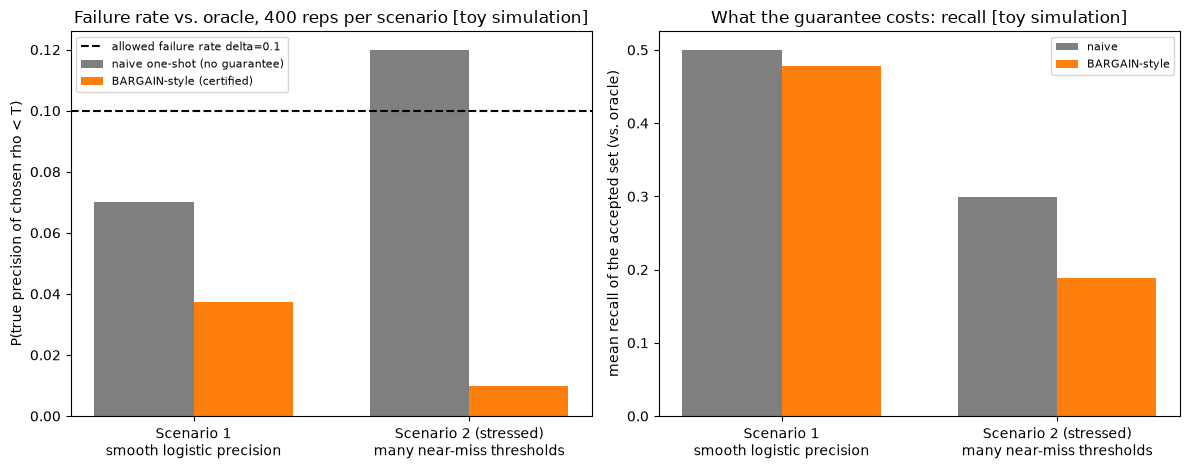

In [13]:
# Visualization only -- uses naive/bargain failure rates and recalls computed above (both scenarios).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
scen = ["Scenario 1\nsmooth logistic precision", "Scenario 2 (stressed)\nmany near-miss thresholds"]
x = np.arange(2)
w = 0.36
ax = axes[0]
ax.bar(x - w/2, [naive_fail_rate, stress_naive_fail_rate], w, color=PALETTE["naive"], label="naive one-shot (no guarantee)")
ax.bar(x + w/2, [bargain_fail_rate, stress_bargain_fail_rate], w, color=PALETTE["bargain"], label="BARGAIN-style (certified)")
ax.axhline(delta, color=PALETTE["truth"], linestyle="--", label=f"allowed failure rate delta={delta}")
ax.set_xticks(x); ax.set_xticklabels(scen)
ax.set_ylabel("P(true precision of chosen rho < T)")
ax.set_title(f"Failure rate vs. oracle, {REPS_S5} reps per scenario [toy simulation]")
ax.legend(fontsize=8)
ax = axes[1]
ax.bar(x - w/2, [np.mean(naive_recall), np.mean(stress_naive_recall)], w, color=PALETTE["naive"], label="naive")
ax.bar(x + w/2, [np.mean(bargain_recall), np.mean(stress_bargain_recall)], w, color=PALETTE["bargain"], label="BARGAIN-style")
ax.set_xticks(x); ax.set_xticklabels(scen)
ax.set_ylabel("mean recall of the accepted set (vs. oracle)")
ax.set_title("What the guarantee costs: recall [toy simulation]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Why recall targets are hard when positives are rare

**Appendix B.6.2** — **Lemma B.11** (an impossibility result): *"Consider
any algorithm that samples a set of $k$ points, $S$, i.i.d. where the probability of a point $x\in D$ is
sampled is monotonically increasing in $\mathcal S(x)$. If the algorithm returns a cascade threshold,
$\rho_S$, that meets the recall target $T$, $T\ge 0.5$, on all datasets of size $n$ and with $n_+$
positives, then, for any dataset $D$, it must have precision*
$$P\Big(\mathcal P_D(\rho_S)\le \frac{n_+}{n}\Big) \ge \Big(1-\frac{n_+}{n}\Big)^k - \delta. \qquad (26)$$
*"Lemma B.11 is insightful when $n_+$ is much smaller than $n$ ... it shows that any algorithm returns
very low precision with high probability, yielding low utility."* The paper's escape hatch is the
$\beta$-relaxation (Lemma B.12: guarantee recall only on the "dense" subset with positive density
$\ge\beta$), with **defaults $\beta=0.02$, $r=150$**.

This ties back directly to §1: recall conditions on the **unobserved** true label, so any recall-target
procedure is, structurally, sampling blind for positives — and when positives are rare ($n_+/n$ small),
$(1-n_+/n)^k$ stays close to 1 even for a healthy budget $k$, meaning **any** monotone-sampling algorithm
is likely to end up with a threshold whose true precision is no better than the base rate.

In [14]:
# Eq. 26's analytic lower bound vs. a direct Monte Carlo of "how many positives does uniform
# sampling find" (the mechanism behind the bound): P(zero positives | prevalence, k) should match
# (1 - prevalence)^k exactly (it's the same event, computed two ways).
rng = np.random.default_rng(RNG_SEED + 8)
delta_S6 = 0.1
prevalences = [0.001, 0.005, 0.02, 0.1]
ks = [100, 400, 1600]
REPS_S6 = 200_000

print(f"{'prevalence':>11} {'k':>6} {'Eq26 bound':>11} {'analytic (1-pi)^k':>18} {'MC P(zero pos)':>15}")
eq26_grid = np.zeros((len(prevalences), len(ks)))
mc_zero_grid = np.zeros((len(prevalences), len(ks)))
for i, pi in enumerate(prevalences):
    for j, k in enumerate(ks):
        bound = max(0.0, (1 - pi) ** k - delta_S6)
        analytic_zero = (1 - pi) ** k
        counts = rng.binomial(k, pi, size=REPS_S6)
        mc_zero = np.mean(counts == 0)
        eq26_grid[i, j] = bound
        mc_zero_grid[i, j] = mc_zero
        print(f"{pi:11.3f} {k:6d} {bound:11.4f} {analytic_zero:18.4f} {mc_zero:15.4f}")

max_abs_diff = np.max(np.abs(mc_zero_grid - (1 - np.array(prevalences))[:, None] ** np.array(ks)[None, :]))
print(f"\nSELF-CHECK: max |MC P(zero positives) - analytic (1-pi)^k| over grid = {max_abs_diff:.4f} "
      f"(expected ~0, same event two ways) -> {'MET' if max_abs_diff < 0.01 else 'NOT MET'}")
print("[MC self-check of an exact identity, not a simulation of anything uncertain]")

# One rare-setting histogram for the visualization: prevalence=0.005, k=400.
pi_rare, k_rare = 0.005, 400
positives_found = rng.binomial(k_rare, pi_rare, size=REPS_S6)


 prevalence      k  Eq26 bound  analytic (1-pi)^k  MC P(zero pos)
      0.001    100      0.8048             0.9048          0.9049
      0.001    400      0.5702             0.6702          0.6705
      0.001   1600      0.1017             0.2017          0.2025
      0.005    100      0.5058             0.6058          0.6062
      0.005    400      0.0347             0.1347          0.1351
      0.005   1600      0.0000             0.0003          0.0004
      0.020    100      0.0326             0.1326          0.1341
      0.020    400      0.0000             0.0003          0.0003
      0.020   1600      0.0000             0.0000          0.0000
      0.100    100      0.0000             0.0000          0.0000
      0.100    400      0.0000             0.0000          0.0000
      0.100   1600      0.0000             0.0000          0.0000

SELF-CHECK: max |MC P(zero positives) - analytic (1-pi)^k| over grid = 0.0015 (expected ~0, same event two ways) -> MET
[MC self-check of an 

**How to read this chart**

Left: a heatmap of Eq. 26's lower bound on $P(\mathcal P_D(\rho_S)\le n_+/n)$ over the (prevalence,
$k$) grid — darker/higher means the impossibility result bites harder (any recall-target algorithm is
likely stuck at base-rate precision). Right: a histogram of "positives found by uniform sampling" for one
rare setting (prevalence 0.005, $k=400$) — most draws find 0–3 positives out of 400 samples, which is
exactly why Lemma B.11's bound is large there. For the audit: **a recall target on a rare GenAI-role tag
cannot be met with a small oracle budget without either a much larger $k$, a better proxy score, or
accepting the $\beta$-relaxation's weaker guarantee.**

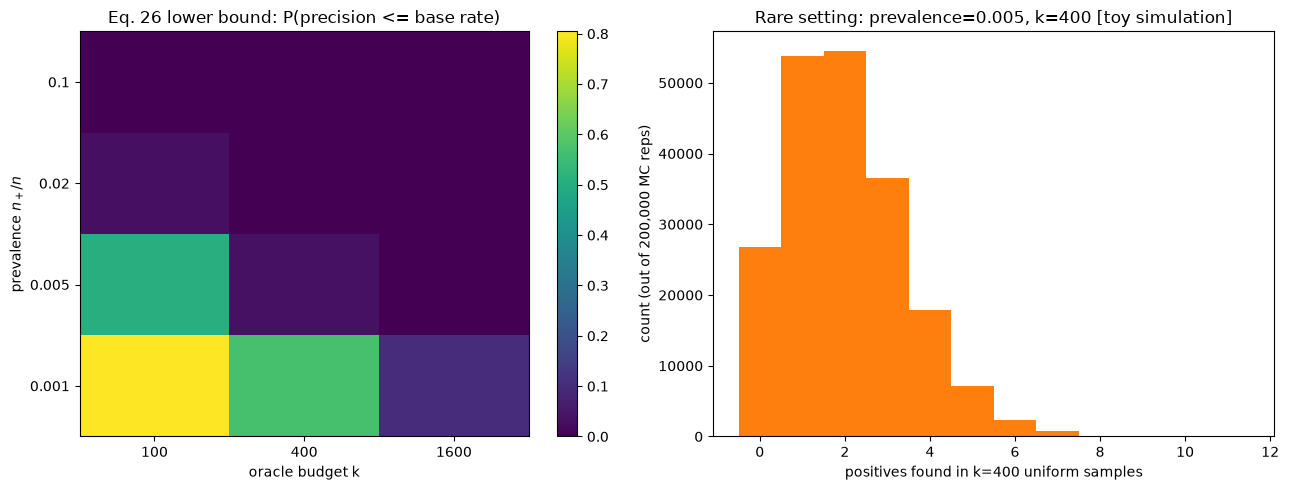

In [15]:
# Visualization only -- uses eq26_grid / positives_found computed above.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(eq26_grid, aspect="auto", cmap="viridis",
               extent=[0, len(ks), 0, len(prevalences)], origin="lower")
ax.set_xticks(np.arange(len(ks)) + 0.5); ax.set_xticklabels(ks)
ax.set_yticks(np.arange(len(prevalences)) + 0.5); ax.set_yticklabels(prevalences)
ax.set_xlabel("oracle budget k")
ax.set_ylabel("prevalence $n_+/n$")
ax.set_title("Eq. 26 lower bound: P(precision <= base rate)")
plt.colorbar(im, ax=ax)

ax = axes[1]
ax.hist(positives_found, bins=np.arange(0, positives_found.max() + 2) - 0.5, color=PALETTE["bargain"])
ax.set_xlabel("positives found in k=400 uniform samples")
ax.set_ylabel("count (out of 200,000 MC reps)")
ax.set_title(f"Rare setting: prevalence={pi_rare}, k={k_rare} [toy simulation]")

plt.tight_layout()
plt.show()


## 7. Monitoring for *harmful* drift (PPRM)

**Section 2.1:** running risk $\bar R_t=\tfrac1t\sum_{t'=1}^t R_{t'}$ (Eq. 2);
harmful-shift condition $\bar R_{t^*}>R_0+\epsilon_{\mathrm{tol}}$ (Eq. 3); hypotheses
$H_0:\bar R_t\le R_0+\epsilon_{\mathrm{tol}}\ \forall t$ (4a) vs. $H_1:\exists t^*$ violating it (4b); type-I
error $P_{H_0}(\exists t:\Phi_t{=}1)\le\delta$ (Eq. 7). **SRM baseline** (Podkopaev & Ramdas 2022):
$U_0=\hat R_0+w_0$ with $P(R_0\le U_0)\ge 1-\delta_S$ (Eq. 10), $L_t=\bar{\hat R}_t - w_t$ with
$P(\bar R_t\ge L_t\ \forall t)\ge 1-\delta_T$ (Eq. 11), decision $\Phi_t=\mathbf 1[L_t>U_0+\epsilon_{\mathrm
tol}]$ (Eq. 13), combined error $\le\delta_S+\delta_T$ (Lemma 2.2). **PPRM estimators** (Eqs. 17–18):
$\hat R_t^{\mathrm{PP}}$ blends a labeled rectifier with an $\eta_t$-weighted unlabeled term; **Lemma
3.1** (unbiased if $\eta_t$ is predictable); **Theorem 3.2** (same $\delta_S+\delta_T$ guarantee as SRM,
Eq. 24); **Lemma 3.3**'s optimal $\eta_t^*=\mathrm{Cov}(u_t,\tilde u_t^{\mathrm L})/((1+n_t/N_t)\mathrm
Var(\tilde u_t^{\mathrm U}))$ (Eq. 26 in PPRM's own numbering).

Harmful vs. any shift — *"such changes do not necessarily indicate harmful
deviations"* (unsupervised drift detectors flag ANY distributional change; PPRM only flags degradation).
Unsupervised monitors need calibration assumptions on the imputing model that are *"difficult to
validate"*; PPRM instead **requires $n_t>0$ labels at every step** and *"[does] not make any assumptions
on the quality of the model $f_p(\cdot)$."* Weak predictors: *"the non-adaptive PPRM may even underperform
SRM due to the use of a poorly calibrated predictor... the adaptive mechanism ... prevents PPRM from
relying too heavily on an uninformative predictor"* (Appendix D.3).

The paper's own evidence (kept separate from the toy numbers below): LLM-QA prompt
shift at $t{=}200$ — *"the true risk exceeds the allowed level at $t=280$, PPRM raises an alarm at around
time $t=500$, whereas SRM raises an alarm at around time $t=530$"*; Table 1 shows fixed-vs-adaptive
$\eta_t$ average time-to-alarm shrinking as the predictor gets stronger (e.g. Qwen2-VL-7B: 519.08 →
498.31). Appendix A.4 gives the approximate delay formulas
$v_S=p(1{-}p)/n$ (39), $v_{\mathrm{PP}}(\eta)=\eta^2q(1{-}q)/N+\tfrac1n(p(1{-}p)+\eta^2q(1{-}q)-2\eta\gamma)$
(40), $\tau_S(\lambda)=\log(1/\delta_T)/(\lambda\Delta-\psi_E(\lambda)v_S)$ (44),
$\tau_{\mathrm{PP}}(\eta)=\log(1/\delta_T)/\big(\tfrac{\lambda\Delta}{1+2\eta}-\tfrac{\psi_E(\lambda)v_{\mathrm{PP}}(\eta)}{(1+2\eta)^2}\big)$
(50), and **Proposition A.1** (Eq. 52): $\tau_{\mathrm{PP}}<\tau_S \iff
2\eta(1{+}2\eta)\lambda\Delta<\psi_E(\lambda)\big((1{+}2\eta)^2v_S-v_{\mathrm{PP}}(\eta)\big)$.

**Implementation note (say it plainly).** PPRM computes its lower bounds with Lemma 2.1 (CM-EB, Howard et al.),
and so does this cell — **Lemma 2.1 with $q(\lambda)$ discretized** (an implementation choice): $q$ is uniform on a grid
of 200 values of $\lambda\in(0,1)$, $\psi_E(\lambda)=-\log(1-\lambda)-\lambda$, $V_t=\sum_{t'\le t}(Z_{t'}-\hat Z_{t'})^2$
with the predictable plug-in $\hat Z_t=\mathrm{clip}(\text{mean of }Z_1..Z_{t-1},0,1)$, $\hat Z_1=\tfrac12$, and
$u(V_t)=\sup\{S:\tfrac1{|grid|}\sum_\lambda e^{\lambda S-\psi_E(\lambda)V_t}<1/\delta_T\}$. Because $u$ depends on $V$ only,
it is tabulated once on a fine grid of $V$ (bisection in $S$, exact since the mixture is increasing in $S$) and
interpolated. The one-sided lower bound is $L_t=\hat\mu_t-u(V_t)/t$ on the **running** mean from $t=1$ — exactly the
quantity PPRM's $H_0/H_1$ are about — and the alarm is $\Phi_t=\mathbf 1[L_t>U_0+\epsilon_{tol}]$. For PPRM, $Z_t$ is the
Eq. 18 per-step PP risk after the affine normalization $g_a(\ell)=(\ell+\eta_{\max})/(1+2\eta_{\max})$ quoted above, and
the threshold is normalized the same way. $U_0$ comes from a Wilson upper bound on the $n_0$ calibration labels
(**derived here** — the paper uses a betting upper bound, App. A.2). Validity is also checked by simulation below.
Because the test is on the *running* risk, alarms necessarily lag the moment the instantaneous risk jumps — the cell
prints the step at which the true running risk actually crosses the threshold next to the alarm times, mirroring the
paper's "risk exceeds at $t=280$, PPRM $\approx500$, SRM $\approx530$". Defaults (the paper's own defaults): $\delta_S=0.05$,
$\delta_T=0.2$, $\eta_0=1$, $L=60$, $n_t=1$, $N_t=15$; calibration $n_0=1{,}000$ labeled.

In [16]:
# --- Lemma 2.1 (CM-EB) lower confidence sequence on the RUNNING mean, with q(lambda) discretized ---
LAM_GRID = (np.arange(200) + 0.5) / 200            # uniform q(lambda) on (0,1), 200 midpoints
PSI_GRID = -np.log(1 - LAM_GRID) - LAM_GRID        # psi_E(lambda) = -log(1-lambda) - lambda  (q8, Lemma 2.1)

def _log_mix(S_val, V_val):
    '''log of  (1/|grid|) * sum_lambda exp(lambda*S - psi_E(lambda)*V)  (discretized mixture integral).'''
    e = LAM_GRID[None, :] * S_val[:, None] - PSI_GRID[None, :] * V_val[:, None]
    mx = e.max(axis=1, keepdims=True)
    return (mx + np.log(np.mean(np.exp(e - mx), axis=1, keepdims=True)))[:, 0]

def cmeb_u_table(delta, V_max, n_grid=4000):
    '''u(V) = sup{S : mixture(S, V) < 1/delta}, tabulated on a V grid (u depends on V only).
    The mixture is increasing in S (every lambda > 0), so bisection is exact.'''
    V_tab = np.concatenate([[0.0], np.geomspace(1e-3, max(V_max, 1e-2), n_grid - 1)])
    lo, hi = np.zeros_like(V_tab), np.full_like(V_tab, 1.0)
    target = np.log(1 / delta)
    while True:                                   # grow hi until mixture(hi) >= 1/delta everywhere
        bad = _log_mix(hi, V_tab) < target
        if not bad.any():
            break
        hi = np.where(bad, hi * 2, hi)
    for _ in range(60):
        mid = (lo + hi) / 2
        below = _log_mix(mid, V_tab) < target
        lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    return V_tab, lo

def cmeb_lower(Z, delta):
    '''One-sided Lemma 2.1 lower bound L_t = mu_hat_t - u(V_t)/t on the running mean of Z in [0,1].
    Z: (S, T). Predictable Z_hat_t = clip(mean(Z_1..Z_{t-1}), 0, 1), Z_hat_1 = 1/2.'''
    S_, T_ = Z.shape
    t_idx = np.arange(1, T_ + 1)[None, :]
    csum = np.cumsum(Z, axis=1)
    mu_hat = csum / t_idx
    z_hat = np.concatenate([np.full((S_, 1), 0.5), np.clip(mu_hat[:, :-1], 0, 1)], axis=1)
    V = np.cumsum((Z - z_hat) ** 2, axis=1)
    V_tab, u_tab = cmeb_u_table(delta, V.max())
    u = np.interp(V, V_tab, u_tab)
    return mu_hat - u / t_idx

def first_alarm(L, threshold):
    cross = L > threshold
    return np.where(cross.any(axis=1), np.argmax(cross, axis=1) + 1, -1)

def wilson_upper(k, n, conf):
    z = NormalDist().inv_cdf(conf)
    phat = k / n
    denom = 1 + z ** 2 / n
    center = (phat + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z ** 2 / (4 * n ** 2)) / denom
    return min(1.0, center + half)

def simulate_streams(T, err_schedule, a, S, rng, eta_mode="fixed", L=60, eta_max=1.0, n_t=1, N_t=15):
    '''Per step: n_t=1 labeled loss u_t ~ Bern(err_t); the auxiliary predictor's loss on it agrees with
    probability a; N_t=15 unlabeled predicted losses are i.i.d. Bern(q_t) with q_t = a*err_t+(1-a)*(1-err_t),
    so their mean is sampled exactly as Binomial(N_t, q_t)/N_t. Returns (labeled loss, g_a-normalized
    PP risk of Eq. 18, eta used).'''
    err = err_schedule[None, :]
    u = rng.binomial(1, np.broadcast_to(err, (S, T))).astype(float)
    agree = rng.uniform(size=(S, T)) < a
    u_L = np.where(agree, u, 1 - u)                                   # predicted loss on the labeled point
    q = a * err + (1 - a) * (1 - err)
    u_U = rng.binomial(N_t, np.broadcast_to(q, (S, T))) / N_t         # mean predicted loss on N_t unlabeled
    eta = np.ones((S, T))
    if eta_mode == "adaptive":
        # Eq. 27-style plug-in on the previous window of L steps (predictable: uses only past data)
        for blk in range(L, T, L):
            uw, uLw, uUw = u[:, blk - L:blk], u_L[:, blk - L:blk], u_U[:, blk - L:blk]
            cov = np.mean((uw - uw.mean(1, keepdims=True)) * (uLw - uLw.mean(1, keepdims=True)), axis=1)
            var_single = np.var(uLw, axis=1)   # Var of a single predicted loss (same marginal as an unlabeled one)
            eta_hat = np.clip(cov / ((1 + n_t / N_t) * (var_single + 1e-8)), 0, eta_max)
            eta[:, blk:] = eta_hat[:, None]
    R_pp = eta * u_U + u - eta * u_L                                  # Eq. 18 per step (n_t = 1)
    return u, (R_pp + eta_max) / (1 + 2 * eta_max), eta

rng = np.random.default_rng(RNG_SEED + 9)

# calibration for U0 (Eq. 9/10): n0=1,000 labeled, nominal error 0.10
n0, nominal_err = 1_000, 0.10
delta_S, delta_T = 0.05, 0.2
eps_tol, eta_max = 0.05, 1.0
k0 = rng.binomial(n0, nominal_err)
U0 = wilson_upper(k0, n0, 1 - delta_S)
m0_srm = U0 + eps_tol
g_a = lambda l: (l + eta_max) / (1 + 2 * eta_max)
m0_pp = g_a(m0_srm)
print(f"U0 (Wilson upper bound, n0={n0}, 1-delta_S={1-delta_S}) = {U0:.4f}")
print(f"alarm threshold U0 + eps_tol = {m0_srm:.4f}  (g_a-normalized for PPRM: {m0_pp:.4f})")

T, S_scn, shift_t = 3_000, 300, 300
err_null = np.full(T, nominal_err)
err_shift = np.where(np.arange(T) < shift_t, nominal_err, 0.25)
true_running = np.cumsum(err_shift) / np.arange(1, T + 1)
t_star = int(np.argmax(true_running > m0_srm) + 1)

# --- The confidence sequence itself: miscoverage on stationary data (should be <= delta_T) ---
Z_check = rng.binomial(1, nominal_err, size=(S_scn, T)).astype(float)
cs_miscover = np.mean((cmeb_lower(Z_check, delta_T) > nominal_err).any(axis=1))
print(f"\nSELF-CHECK: Lemma 2.1 (discretized) lower CS ever above the true mean = {cs_miscover:.4f} "
      f"(expected <= delta_T={delta_T}) -> {'MET' if cs_miscover <= delta_T else 'NOT MET'}")

# --- Scenario A: null (no shift) -- false-alarm rate ---
labeled_null, pp_null, _ = simulate_streams(T, err_null, 0.9, S_scn, rng)
srm_alarm_null = first_alarm(cmeb_lower(labeled_null, delta_T), m0_srm)
pp_alarm_null = first_alarm(cmeb_lower(pp_null, delta_T), m0_pp)
srm_fa_rate = np.mean(srm_alarm_null > 0)
pp_fa_rate = np.mean(pp_alarm_null > 0)
print(f"SELF-CHECK: (A) null false-alarm rate, SRM  = {srm_fa_rate:.4f} "
      f"(expected <= delta_S+delta_T={delta_S+delta_T}) -> {'MET' if srm_fa_rate <= delta_S+delta_T else 'NOT MET'}")
print(f"SELF-CHECK: (A) null false-alarm rate, PPRM = {pp_fa_rate:.4f} "
      f"(expected <= delta_S+delta_T={delta_S+delta_T}) -> {'MET' if pp_fa_rate <= delta_S+delta_T else 'NOT MET'}")

# --- Scenarios B & D: harmful shift at t=300 (error 0.10 -> 0.25), good (a=0.9) vs weak (a=0.55) predictor ---
print(f"\nharmful shift at t={shift_t}; the TRUE running risk first exceeds U0+eps_tol at t*={t_star} "
      f"(alarms on running risk can only come after this)")
results = {}
example = {}
for a_val, tag in [(0.9, "B_good"), (0.55, "D_weak")]:
    labeled, pp_fixed, _ = simulate_streams(T, err_shift, a_val, S_scn, np.random.default_rng(500 + int(a_val * 100)))
    _, pp_adapt, eta_used = simulate_streams(T, err_shift, a_val, S_scn, np.random.default_rng(500 + int(a_val * 100)),
                                             eta_mode="adaptive", L=60)
    L_srm, L_ppf, L_ppa = cmeb_lower(labeled, delta_T), cmeb_lower(pp_fixed, delta_T), cmeb_lower(pp_adapt, delta_T)
    results[tag] = {"srm": first_alarm(L_srm, m0_srm), "pprm_fixed": first_alarm(L_ppf, m0_pp),
                    "pprm_adaptive": first_alarm(L_ppa, m0_pp)}
    if tag == "B_good":   # keep one stream's bounds (back on the original loss scale) for panel (i)
        example = {"L_srm": L_srm[0], "L_pprm": L_ppf[0] * (1 + 2 * eta_max) - eta_max,
                   "t_srm": results[tag]["srm"][0], "t_pprm": results[tag]["pprm_fixed"][0]}
    print(f"Scenario {tag} (a={a_val}); mean adaptive eta after t=600: {eta_used[:, 600:].mean():.3f}")
    for method, t in results[tag].items():
        tt = t[t > 0]
        print(f"  {method:14s}: alarmed {len(tt):3d}/{S_scn}  median t={np.median(tt) if len(tt) else float('nan'):7.1f}")

med = lambda tag, mth: np.median(results[tag][mth][results[tag][mth] > 0])
good_faster = med("B_good", "pprm_fixed") < med("B_good", "srm")
weak_slower = med("D_weak", "pprm_fixed") > med("D_weak", "srm")
weak_adapt_closer = abs(med("D_weak", "pprm_adaptive") - med("D_weak", "srm")) < abs(med("D_weak", "pprm_fixed") - med("D_weak", "srm"))
print(f"\nSELF-CHECK: good predictor (a=0.9): PPRM-fixed alarms faster than SRM -> {'MET' if good_faster else 'NOT MET'} "
      f"(paper's evidence, q9: risk exceeds t=280, PPRM ~500, SRM ~530 -- a different task, not comparable in absolute t)")
print(f"SELF-CHECK: weak predictor (a=0.55): fixed-eta PPRM slower than SRM -> {'MET' if weak_slower else 'NOT MET'} (App. D.3)")
print(f"SELF-CHECK: weak predictor: adaptive-eta PPRM closer to SRM than fixed-eta -> {'MET' if weak_adapt_closer else 'NOT MET'} (App. D.3)")
print(f"SELF-CHECK: every median alarm comes after t*={t_star} -> "
      f"{'MET' if all(med(tg, m) >= t_star for tg in results for m in results[tg]) else 'NOT MET'}")
print("[toy simulation numbers -- not the paper's own t=280/500/530]")


U0 (Wilson upper bound, n0=1000, 1-delta_S=0.95) = 0.1178
alarm threshold U0 + eps_tol = 0.1678  (g_a-normalized for PPRM: 0.3893)



SELF-CHECK: Lemma 2.1 (discretized) lower CS ever above the true mean = 0.0067 (expected <= delta_T=0.2) -> MET


SELF-CHECK: (A) null false-alarm rate, SRM  = 0.0000 (expected <= delta_S+delta_T=0.25) -> MET
SELF-CHECK: (A) null false-alarm rate, PPRM = 0.0000 (expected <= delta_S+delta_T=0.25) -> MET

harmful shift at t=300; the TRUE running risk first exceeds U0+eps_tol at t*=548 (alarms on running risk can only come after this)


Scenario B_good (a=0.9); mean adaptive eta after t=600: 0.670
  srm           : alarmed 300/300  median t=  958.5
  pprm_fixed    : alarmed 300/300  median t=  870.5
  pprm_adaptive : alarmed 300/300  median t=  829.5


Scenario D_weak (a=0.55); mean adaptive eta after t=600: 0.087
  srm           : alarmed 300/300  median t=  967.5
  pprm_fixed    : alarmed 300/300  median t= 1239.5
  pprm_adaptive : alarmed 300/300  median t=  962.5

SELF-CHECK: good predictor (a=0.9): PPRM-fixed alarms faster than SRM -> MET (paper's evidence, q9: risk exceeds t=280, PPRM ~500, SRM ~530 -- a different task, not comparable in absolute t)
SELF-CHECK: weak predictor (a=0.55): fixed-eta PPRM slower than SRM -> MET (App. D.3)
SELF-CHECK: weak predictor: adaptive-eta PPRM closer to SRM than fixed-eta -> MET (App. D.3)
SELF-CHECK: every median alarm comes after t*=548 -> MET
[toy simulation numbers -- not the paper's own t=280/500/530]


In [17]:
# --- Scenario C: benign shift (prevalence of predicted class changes, error stays 0.10) ---
# A two-sample permutation test on predicted-label frequencies ("derived here") should flag it;
# PPRM/SRM (which watch RISK, not label frequency) should not alarm above the baseline rate.
rng = np.random.default_rng(RNG_SEED + 10)
S_C, block = 300, 300
q_pre, q_post = 0.5, 0.7   # predicted-positive rate shifts at the changepoint; error rate does not
pred_pre = rng.binomial(1, q_pre, size=(S_C, block))
pred_post = rng.binomial(1, q_post, size=(S_C, block))

def perm_test_pvalues(pred_pre, pred_post, rng, reps=1000):
    '''Permutation test via the hypergeometric null (resampling w/o replacement from the pooled
    counts is EXACTLY the hypergeometric distribution -- no need to shuffle raw arrays).'''
    S, n = pred_pre.shape
    k_pre, k_post = pred_pre.sum(axis=1), pred_post.sum(axis=1)
    N, K = 2 * n, k_pre + k_post
    obs_diff = np.abs(k_pre / n - k_post / n)
    null_k_pre = rng.hypergeometric(K.astype(np.int64)[None, :], (N - K).astype(np.int64)[None, :], n, size=(reps, S))
    null_diff = np.abs(null_k_pre / n - (K[None, :] - null_k_pre) / n)
    return np.mean(null_diff >= obs_diff[None, :], axis=0)

pvals_shift = perm_test_pvalues(pred_pre, pred_post, rng)
perm_detect_rate = np.mean(pvals_shift < 0.05)
# risk process is unaffected by this benign shift -- reuse the null false-alarm rates from Scenario A
print(f"SELF-CHECK: (C) permutation test detection rate of the benign prevalence shift = {perm_detect_rate:.4f} "
      f"(expected: high, this IS a real distributional change) -> {'MET' if perm_detect_rate > 0.8 else 'NOT MET'}")
print(f"SELF-CHECK: (C) PPRM/SRM alarm rate on the SAME benign shift = risk-process false-alarm rate "
      f"(reusing Scenario A, since error stays at {nominal_err}): SRM={srm_fa_rate:.4f} PPRM={pp_fa_rate:.4f} "
      f"(expected: near the Scenario-A baseline, NOT elevated -- 'such changes do not necessarily "
      f"indicate harmful deviations', q10)")

# --- Analytic cell: Appendix A.4 Eqs. 39, 40, 44, 50 and Proposition A.1's Eq. 52 boundary ---
p_true, theta_thr, q_pred = 0.25, 0.20, 0.25
Delta_margin = p_true - theta_thr
n_lab, N_unlab, lam_bet = 5, 200, 0.8   # illustrative parameter choice, not paper defaults
def psi_E(l): return -np.log(1 - l) - l
v_S = p_true * (1 - p_true) / n_lab
tau_S = np.log(1 / delta_T) / (lam_bet * Delta_margin - psi_E(lam_bet) * v_S)

etas_grid = np.linspace(0.001, 1.5, 120)
gmax = np.sqrt(p_true * (1 - p_true) * q_pred * (1 - q_pred))
gammas_grid = np.linspace(-gmax, gmax, 120)
E, G = np.meshgrid(etas_grid, gammas_grid)
v_PP = (E ** 2 * q_pred * (1 - q_pred)) / N_unlab + (1 / n_lab) * (p_true * (1 - p_true) + E ** 2 * q_pred * (1 - q_pred) - 2 * E * G)
denom_pp = lam_bet * Delta_margin / (1 + 2 * E) - psi_E(lam_bet) * v_PP / (1 + 2 * E) ** 2
tau_PP = np.where(denom_pp > 0, np.log(1 / delta_T) / np.maximum(denom_pp, 1e-12), np.nan)
ratio_tau = tau_PP / tau_S
cond52 = 2 * E * (1 + 2 * E) * lam_bet * Delta_margin < psi_E(lam_bet) * ((1 + 2 * E) ** 2 * v_S - v_PP)
agreement = np.nanmean((ratio_tau < 1).astype(float) == cond52.astype(float))
print(f"\ntau_S (Eq. 44, illustrative params p={p_true},theta={theta_thr},n={n_lab},lambda={lam_bet}) = {tau_S:.1f}")
print(f"SELF-CHECK: Eq. 52's sign condition agrees with tau_PP/tau_S < 1 over the (eta,gamma) grid = "
      f"{agreement:.4f} (expected 1.0, they are the same statement) -> {'MET' if agreement > 0.99 else 'NOT MET'}")
print("[analytic identity check, not a Monte Carlo simulation]")


SELF-CHECK: (C) permutation test detection rate of the benign prevalence shift = 0.9967 (expected: high, this IS a real distributional change) -> MET
SELF-CHECK: (C) PPRM/SRM alarm rate on the SAME benign shift = risk-process false-alarm rate (reusing Scenario A, since error stays at 0.1): SRM=0.0000 PPRM=0.0000 (expected: near the Scenario-A baseline, NOT elevated -- 'such changes do not necessarily indicate harmful deviations', q10)

tau_S (Eq. 44, illustrative params p=0.25,theta=0.2,n=5,lambda=0.8) = 166.8
SELF-CHECK: Eq. 52's sign condition agrees with tau_PP/tau_S < 1 over the (eta,gamma) grid = 1.0000 (expected 1.0, they are the same statement) -> MET
[analytic identity check, not a Monte Carlo simulation]


**How to read this chart**

Four panels. **(i, top-left)** one harmful-shift stream: the black curve is the true *running* risk, which starts
rising at the shift ($t{=}300$) but only crosses the red alarm threshold at $t^*$; grey and blue are the SRM and PPRM
(Lemma 2.1) lower bounds, which must stay below the black curve, and the dashed vertical lines mark each method's alarm
(the first time its lower bound clears the red line) — PPRM's tighter bound should clear it sooner. **(ii, top-right)** time-to-alarm boxplots per method for
the good-predictor (B) and weak-predictor (D) scenarios — PPRM-fixed should beat SRM in B and lose to it
in D, with PPRM-adaptive sitting between them (closer to SRM) in D. **(iii, bottom-left)** the cumulative
false-alarm rate over time for the null scenario (A), which must stay under the $\delta_S+\delta_T$ line
throughout — not just at the end. **(iv, bottom-right)** a heatmap of $\tau_{\mathrm{PP}}/\tau_S$ over
$(\gamma,\eta)$ with the Eq. 52 boundary overlaid (dashed) — below/left of the boundary PPRM's
analytic delay beats SRM's; above/right it doesn't. For the audit: **PPRM only helps when the auxiliary
predictor is genuinely informative** (high $\gamma$, moderate $\eta$) — with a weak or uncorrelated
predictor, plain labeled-only monitoring (SRM) is not worse, and can be better with a badly-tuned fixed
$\eta$.

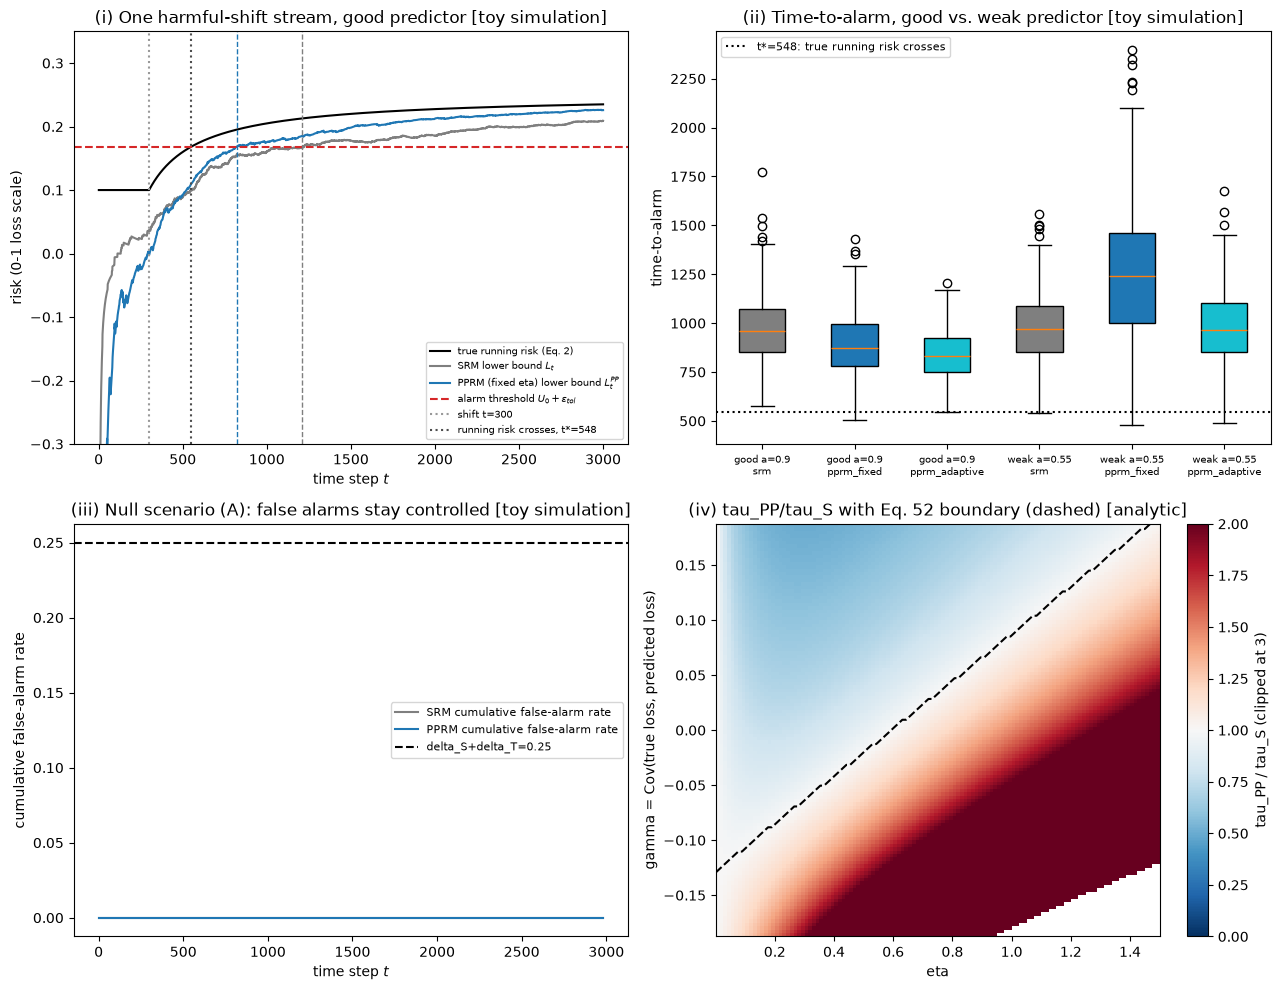

In [18]:
# Visualization only -- uses labeled_null/pp_null, results[...], cond52/ratio_tau computed above.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
tt_axis = np.arange(1, T + 1)
ax.plot(tt_axis, true_running, color=PALETTE["truth"], lw=1.5, label="true running risk (Eq. 2)")
ax.plot(tt_axis, example["L_srm"], color=PALETTE["srm"], label="SRM lower bound $L_t$")
ax.plot(tt_axis, example["L_pprm"], color=PALETTE["pprm"], label="PPRM (fixed eta) lower bound $L_t^{PP}$")
ax.axhline(m0_srm, color="tab:red", linestyle="--", label="alarm threshold $U_0+\\epsilon_{tol}$")
ax.axvline(shift_t, color="0.6", linestyle=":", label=f"shift t={shift_t}")
ax.axvline(t_star, color="0.3", linestyle=":", label=f"running risk crosses, t*={t_star}")
for t_al, c in [(example["t_srm"], PALETTE["srm"]), (example["t_pprm"], PALETTE["pprm"])]:
    if t_al > 0:
        ax.axvline(t_al, color=c, linestyle="--", lw=1)
ax.set_ylim(-0.3, 0.35)
ax.set_xlabel("time step $t$"); ax.set_ylabel("risk (0-1 loss scale)")
ax.set_title("(i) One harmful-shift stream, good predictor [toy simulation]")
ax.legend(fontsize=7, loc="lower right")

ax = axes[0, 1]
box_data, box_labels, box_colors = [], [], []
for tag, label in [("B_good", "good a=0.9"), ("D_weak", "weak a=0.55")]:
    for method, mcolor in [("srm", PALETTE["srm"]), ("pprm_fixed", PALETTE["pprm_fixed"]),
                            ("pprm_adaptive", PALETTE["pprm_adaptive"])]:
        t = results[tag][method]
        t = t[t > 0]
        box_data.append(t if len(t) else [np.nan])
        box_labels.append(f"{label}\n{method}")
        box_colors.append(mcolor)
bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
ax.axhline(t_star, color=PALETTE["truth"], linestyle=":", label=f"t*={t_star}: true running risk crosses")
ax.set_ylabel("time-to-alarm")
ax.set_title("(ii) Time-to-alarm, good vs. weak predictor [toy simulation]")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=7)

ax = axes[1, 0]
t_grid = np.arange(1, T + 1, 20)
srm_cum = [np.mean((srm_alarm_null > 0) & (srm_alarm_null <= tt)) for tt in t_grid]
pp_cum = [np.mean((pp_alarm_null > 0) & (pp_alarm_null <= tt)) for tt in t_grid]
ax.plot(t_grid, srm_cum, color=PALETTE["srm"], label="SRM cumulative false-alarm rate")
ax.plot(t_grid, pp_cum, color=PALETTE["pprm"], label="PPRM cumulative false-alarm rate")
ax.axhline(delta_S + delta_T, color=PALETTE["truth"], linestyle="--", label=f"delta_S+delta_T={delta_S+delta_T}")
ax.set_xlabel("time step $t$"); ax.set_ylabel("cumulative false-alarm rate")
ax.set_title("(iii) Null scenario (A): false alarms stay controlled [toy simulation]")
ax.legend(fontsize=8)

ax = axes[1, 1]
im = ax.imshow(np.clip(ratio_tau, 0, 3), origin="lower", aspect="auto", cmap="RdBu_r",
               extent=[etas_grid.min(), etas_grid.max(), gammas_grid.min(), gammas_grid.max()], vmin=0, vmax=2)
ax.contour(etas_grid, gammas_grid, cond52.astype(float), levels=[0.5], colors=[PALETTE["truth"]], linestyles="--")
ax.set_xlabel("eta"); ax.set_ylabel("gamma = Cov(true loss, predicted loss)")
ax.set_title("(iv) tau_PP/tau_S with Eq. 52 boundary (dashed) [analytic]")
plt.colorbar(im, ax=ax, label="tau_PP / tau_S (clipped at 3)")

plt.tight_layout()
plt.show()


## 8. Near-duplicate reposts: MinHash, LSH, and why duplicates break the audit's i.i.d. assumption

*(**Derived here — not from the three papers.** Standard references: Broder, A. (1997), "On the
resemblance and containment of documents," Compression and Complexity of Sequences; Leskovec,
Rajaraman & Ullman, *Mining of Massive Datasets*, 3rd ed., Ch. 3.)*

MinHash: for a random permutation-equivalent hash $h$, $P[h_{\min}(A)=h_{\min}(B)]=J(A,B)$ (the Jaccard
similarity of the two shingle sets). With $k$ independent hashes, $\hat J=$ (fraction of the $k$ minhashes
that agree) is an unbiased estimator of $J$ with $\mathrm{SD}=\sqrt{J(1-J)/k}$. LSH banding into $b$ bands
of $r$ rows each gives candidate-pair probability $1-(1-s^r)^b$ for true similarity $s$.

**Why this belongs next to §2–§3's assumptions**: PPI's validity rests entirely on i.i.d. sampling —
quoted from the paper, "$(X,Y)$ and $(\tilde X,\tilde Y)$ are independently and identically
distributed samples from a **common** distribution $P$." A job-posting audit sample that is 20% exact or
near-exact reposts of other sampled postings is **not** an i.i.d. sample of the *effective* population of
distinct postings — the duplicates are perfectly correlated with their originals, so the **effective
sample size is smaller than $n$**, and any interval computed as if $n$ independent draws were observed
(Wald, Wilson, or even PPI's own normal-approximation interval, all of which assume i.i.d. observations)
will be **too narrow**. MinHash/LSH is the standard, cheap way to find and remove those duplicates at
100K+ scale before running any of the §1–§7 machinery.

In [19]:
# Two synthetic "posting" texts at several edit levels, word-3-gram shingles, MinHash via
# universal hashing (a*x+b) mod p on stable 64-bit hashes (hashlib.blake2b, not Python's salted hash()).
rng = np.random.default_rng(RNG_SEED + 11)
P_HASH = (1 << 31) - 1   # Mersenne prime; keeps a*h products inside int64 range

def shingles(text, n=3):
    words = text.split()
    return set(tuple(words[i:i + n]) for i in range(len(words) - n + 1))

def stable_hash(shingle):
    h = hashlib.blake2b(("|".join(shingle)).encode(), digest_size=8)
    return int.from_bytes(h.digest(), "big") % P_HASH

def edit_text(text, edit_rate, rng, vocab):
    out = []
    for w in text.split():
        if rng.uniform() < edit_rate:
            choice = rng.integers(0, 3)
            if choice == 0:
                continue                              # delete
            elif choice == 1:
                out.append(rng.choice(vocab))          # substitute
            else:
                out.append(w); out.append(rng.choice(vocab))   # insert after
        else:
            out.append(w)
    return " ".join(out)

vocab = [f"w{i}" for i in range(200)]
base_text = " ".join(rng.choice(vocab, size=300))
A_sh = shingles(base_text)
hashesA = np.array([stable_hash(s) for s in A_sh], dtype=np.int64)

edit_rate_probe = 0.15
B_text = edit_text(base_text, edit_rate_probe, rng, vocab)
B_sh = shingles(B_text)
hashesB = np.array([stable_hash(s) for s in B_sh], dtype=np.int64)
J_true = len(A_sh & B_sh) / len(A_sh | B_sh)
print(f"Two synthetic postings at edit_rate={edit_rate_probe}: true Jaccard J = {J_true:.4f}\n")

def mc_minhash(hashesA, hashesB, k, reps, rng):
    ests = np.empty(reps)
    for r in range(reps):
        a = rng.integers(1, P_HASH, size=k, dtype=np.int64)
        b = rng.integers(0, P_HASH, size=k, dtype=np.int64)
        sigA = ((a[None, :] * hashesA[:, None] + b[None, :]) % P_HASH).min(axis=0)
        sigB = ((a[None, :] * hashesB[:, None] + b[None, :]) % P_HASH).min(axis=0)
        ests[r] = np.mean(sigA == sigB)
    return ests

print(f"{'k':>5} {'mean Jhat':>10} {'true J':>8} {'empirical SD':>13} {'theoretical SD':>15}")
minhash_results = {}
for k in [32, 128, 512]:
    ests = mc_minhash(hashesA, hashesB, k, 300, rng)
    theo_sd = np.sqrt(J_true * (1 - J_true) / k)
    minhash_results[k] = (ests.mean(), ests.std(), theo_sd)
    print(f"{k:5d} {ests.mean():10.4f} {J_true:8.4f} {ests.std():13.4f} {theo_sd:15.4f}")

max_sd_rel_err = max(abs(v[1] - v[2]) / v[2] for v in minhash_results.values())
print(f"\nSELF-CHECK: max relative error, empirical vs theoretical MinHash SD = {max_sd_rel_err:.3f} "
      f"(expected small, <0.20 at these MC rep counts) -> {'MET' if max_sd_rel_err < 0.20 else 'NOT MET'}")


Two synthetic postings at edit_rate=0.15: true Jaccard J = 0.4615

    k  mean Jhat   true J  empirical SD  theoretical SD
   32     0.4609   0.4615        0.0876          0.0881


  128     0.4630   0.4615        0.0452          0.0441


  512     0.4606   0.4615        0.0222          0.0220

SELF-CHECK: max relative error, empirical vs theoretical MinHash SD = 0.027 (expected small, <0.20 at these MC rep counts) -> MET


In [20]:
# LSH S-curve: empirical candidate rate for (b, r) in {(20,5), (50,2), (10,10)} (k = b*r = 100),
# overlaid on the theoretical curve 1-(1-s^r)^b, across several true-similarity levels.
rng = np.random.default_rng(RNG_SEED + 12)
k_lsh = 100
bandings = [(20, 5), (50, 2), (10, 10)]
edit_rates_lsh = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
lsh_points = {band: [] for band in bandings}
true_Js = []

for er in edit_rates_lsh:
    Bt = edit_text(base_text, er, rng, vocab)
    B_sh_i = shingles(Bt)
    J_i = len(A_sh & B_sh_i) / len(A_sh | B_sh_i)
    true_Js.append(J_i)
    hashesB_i = np.array([stable_hash(s) for s in B_sh_i], dtype=np.int64)
    counts = {band: 0 for band in bandings}
    reps_lsh = 300
    for _ in range(reps_lsh):
        a = rng.integers(1, P_HASH, size=k_lsh, dtype=np.int64)
        b = rng.integers(0, P_HASH, size=k_lsh, dtype=np.int64)
        sigA = ((a[None, :] * hashesA[:, None] + b[None, :]) % P_HASH).min(axis=0)
        sigB = ((a[None, :] * hashesB_i[:, None] + b[None, :]) % P_HASH).min(axis=0)
        match = sigA == sigB
        for (bb, rr) in bandings:
            bands = match[:bb * rr].reshape(bb, rr)
            counts[(bb, rr)] += np.any(bands.all(axis=1))
    for band in bandings:
        lsh_points[band].append(counts[band] / reps_lsh)

print("Empirical candidate rate by banding (b, r), across true Jaccard similarity levels:")
print(f"{'true J':>8}" + "".join(f"  (b={b},r={r})".rjust(14) for b, r in bandings))
for i, J_i in enumerate(true_Js):
    print(f"{J_i:8.3f}" + "".join(f"{lsh_points[band][i]:14.3f}" for band in bandings))
print("\n[toy simulation -- two synthetic postings at increasing edit distance, not real job postings]")

# Tiny simulation, same cell: audit sample of n=300 where 20% are EXACT duplicates of other sampled
# items. Bootstrap-with-replacement from a fixed finite binary sample is exactly equivalent to
# redrawing Binomial(n, phat), so duplicating rows is simulated directly by re-using drawn labels.
rng = np.random.default_rng(RNG_SEED + 13)
p_true_dedup = 0.30
n_total, dup_frac = 300, 0.20
n_dup = int(n_total * dup_frac)
n_unique = n_total - n_dup
REPS_S8 = 20_000

cov_with_dup, cov_dedup = 0, 0
for _ in range(REPS_S8):
    Y_unique = rng.binomial(1, p_true_dedup, size=n_unique)
    dup_idx = rng.integers(0, n_unique, size=n_dup)
    Y_full = np.concatenate([Y_unique, Y_unique[dup_idx]])
    lo, hi = wilson_ci(Y_full.sum(), n_total)
    cov_with_dup += (lo <= p_true_dedup <= hi)
    lo2, hi2 = wilson_ci(Y_unique.sum(), n_unique)
    cov_dedup += (lo2 <= p_true_dedup <= hi2)

cov_with_dup /= REPS_S8
cov_dedup /= REPS_S8
print(f"SELF-CHECK: Wilson 95% coverage WITH 20% exact duplicates (naive n={n_total}) = {cov_with_dup:.4f} "
      f"(expected: drops below 0.95) -> {'MET' if cov_with_dup < 0.94 else 'NOT MET'}")
print(f"SELF-CHECK: Wilson 95% coverage DEDUPLICATED (n={n_unique} unique items) = {cov_dedup:.4f} "
      f"(expected: back near 0.95) -> {'MET' if cov_dedup > 0.92 else 'NOT MET'}")
print("[toy simulation numbers]")


Empirical candidate rate by banding (b, r), across true Jaccard similarity levels:
  true J    (b=20,r=5)    (b=50,r=2)   (b=10,r=10)
   1.000         1.000         1.000         1.000
   0.830         1.000         1.000         0.820
   0.676         0.967         1.000         0.183
   0.384         0.113         1.000         0.000
   0.235         0.007         0.940         0.000
   0.147         0.000         0.670         0.000
   0.036         0.000         0.063         0.000
   0.007         0.000         0.003         0.000

[toy simulation -- two synthetic postings at increasing edit distance, not real job postings]


SELF-CHECK: Wilson 95% coverage WITH 20% exact duplicates (naive n=300) = 0.8941 (expected: drops below 0.95) -> MET
SELF-CHECK: Wilson 95% coverage DEDUPLICATED (n=240 unique items) = 0.9431 (expected: back near 0.95) -> MET
[toy simulation numbers]


**How to read this chart**

The x-axis is true Jaccard similarity $s$ (from the edited postings above); the y-axis is candidate-pair
probability. Three theoretical S-curves for $(b,r)\in\{(20,5),(50,2),(10,10)\}$ (all with $k{=}100$
hashes) are drawn as lines; the empirical candidate rates from the MC above are overlaid as markers of
matching color. $(50,2)$ is "loose" (flags candidates even at modest similarity — few false negatives,
more false positives to verify); $(10,10)$ is "strict" (only very similar pairs become candidates). For
the audit at 100K+ postings/month: **pick the banding by how much false-positive verification cost you
can tolerate versus how many near-duplicate reposts you can afford to miss** before they inflate your
audit sample's apparent size.

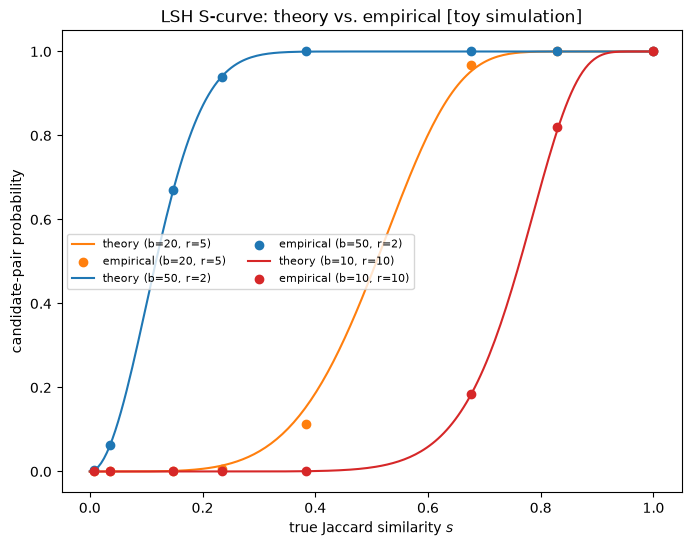

In [21]:
# Visualization only -- uses lsh_points / true_Js computed above.
fig, ax = plt.subplots(figsize=(8, 6))
s_fine = np.linspace(0, 1, 200)
colors_bands = [PALETTE["bargain"], PALETTE["ppi"], PALETTE["peeking"]]
for (b, r), color in zip(bandings, colors_bands):
    theo_curve = 1 - (1 - s_fine ** r) ** b
    ax.plot(s_fine, theo_curve, color=color, label=f"theory (b={b}, r={r})")
    ax.scatter(true_Js, lsh_points[(b, r)], color=color, marker="o", zorder=5,
               label=f"empirical (b={b}, r={r})")
ax.set_xlabel("true Jaccard similarity $s$")
ax.set_ylabel("candidate-pair probability")
ax.set_title("LSH S-curve: theory vs. empirical [toy simulation]")
ax.legend(fontsize=8, ncol=2)
plt.show()


## Closing: measure → decide → monitor, four audit insights, and hand-off to Notebook 2

**Three roles, one shared toolkit.** **PPI** (§1–§3) *measures* a population parameter — prevalence,
precision, an error rate — from a small labeled audit plus a large unlabeled stream, with a rectified
estimator that is valid *no matter how bad the predictor is*, and it needs the label-shift/covariate-shift
machinery the moment the audit and the stream stop being i.i.d. **BARGAIN** (§4–§6) *decides* where to
route each record between a cheap proxy and an expensive oracle, using an anytime-valid betting statistic
to certify a precision/recall target **against the oracle's own output** — with a proven impossibility
result for recall targets when positives are rare. **PPRM** (§7) *monitors* the deployed system over time
for **harmful** (not just any) drift, combining a labeled trickle with an unlabeled flood the same way PPI
does, wrapped in an anytime-valid confidence sequence so the alarm's false-positive rate holds up under
continuous checking.

**Four audit insights, in one place:**
1. **Recall is structurally expensive, precision is cheap** (§1, §6) — precision conditions on your own
   predicted-positive set; recall conditions on the unobserved true positives, and Lemma B.11's
   impossibility result says no monotone-sampling algorithm escapes this when positives are rare.
2. **A predictor doesn't need to be good to be useful — but it does need to be good enough** (§2, §7) — PPI
   and PPRM are both valid regardless of the proxy/predictor's accuracy, but *useful* (narrower than
   classical / faster than SRM) only past a break-even accuracy the notebook derives and checks by
   simulation.
3. **i.i.d. is a load-bearing assumption, and job-posting streams violate it twice** (§3, §8) — once
   across months (label shift, needing the confusion-matrix correction) and once within a single audit
   sample (near-duplicate reposts, needing MinHash/LSH dedup before anything else runs).
4. **Peeking is not free, and a fixed CLT interval is not an audit dashboard** (§4, §5, §7) — every
   guarantee in this notebook that gets checked "whenever you feel like it" (a cascade threshold audit, a
   monthly drift check) needs an anytime-valid / betting-based statistic, not a single-shot Wald or CLT
   interval re-checked repeatedly.

**What this notebook is not.** None of the three source papers unifies these three methods into a
single monthly lifecycle: BARGAIN's guarantees are proven for a **static
batch** $D$ with no rule for adapting the cascade threshold under streaming drift, and its accuracy/
precision/recall are relative to the **oracle's own output**, not to human ground truth (that gap is
filled by PPI, run separately against the monthly human-labeled audit). The architecture that stitches
BARGAIN routing + PPI estimation + PPRM monitoring into one monthly cycle is **this project's design**,
not a claim from any of the three papers.

**Hand-off to Notebooks 2 and 3.** Notebook 2 builds a synthetic job-posting corpus with known latent truth,
wires up the keyword-taxonomy rules plus a real DeepSeek LLM fallback tier, and runs an audit baseline
with §1's Wilson intervals, including an empirical sweep of where the rules/LLM boundary should sit. Notebook 3
then applies this notebook's machinery to that stack: BARGAIN-style certified routing (§4–§5), PPI estimates
against a monthly human audit (§2–§3), PPRM-style harmful-drift monitoring (§7), and MinHash dedup before audit
sampling (§8).